In [1]:
# ============================================================
# SINGLE-SVR DIGITAL TWIN — Polished_Stack_Model refactored
# Architecture: Physics(ECU inputs) + ONE retrained SVR
# The open-loop SVR (Cell 4 in old notebook) is REMOVED.
# The retrained SVR in Cell 11 is now the ONLY ML corrector.
# ============================================================

Defining Constants + Fundamental Physics 

In [2]:
# ============================================================
# CELL 1: DEFINING CONSTANTS + FUNDAMENTAL PHYSICS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ── Physical constants ───────────────────────────────────────
F, R, n_electrons, E0, N_cells = 96485.0, 8.314, 2.0, 1.229, 330.0
TAU_THERMAL, TAU_LAMBDA, LAB_RH = 30.0, 5.0, 0.48
tm = 8.5e-6
cp_coolant, x_O2 = 3450.0, 0.21
M_stack, Cp_stack, E_th, Area = 56.0, 500.0, 1.48, 0.0297

def calculate_lambda_base(rh):
    return 0.043 + 17.81*rh - 39.85*(rh**2) + 36.0*(rh**3)

def nernst_voltage(T, P_H2_pa, P_air_pa, P_H2O_pa):
    P_atmo = 101325.0
    P_H2_atm  = P_H2_pa  / P_atmo
    P_air_atm = P_air_pa / P_atmo
    P_H2O_atm = P_H2O_pa / P_atmo
    P_O2_atm  = x_O2 * (P_air_atm - P_H2O_atm)
    inner_log = (P_H2_atm * P_O2_atm**0.5) / np.maximum(P_H2O_atm, 1e-6)
    return E0 + (R * T / (n_electrons * F)) * np.log(np.maximum(inner_log, 1e-10))

def cell_voltage(i, T, P_H2, P_air, P_H2O, params, l_dynamic):
    i_n, i_0, alpha, k_lambda, m_trans, n_growth, k_dry = params
    sigma   = (0.005139 * l_dynamic - 0.00326) * np.exp(1268 * (1/303 - 1/T)) * 100.0
    V_ohmic = i * (tm / np.maximum(sigma, 1e-6))
    V_n     = nernst_voltage(T, P_H2, P_air, P_H2O)
    V_act   = (R * T / (alpha * n_electrons * F)) * np.log((i + i_n) / np.maximum(i_0, 1e-12))
    V_conc  = m_trans * (np.exp(n_growth * i) - 1)
    return (V_n - V_act - V_ohmic - V_conc) * N_cells

Loading & Converting CSV Data

In [3]:
# ============================================================
# CELL 2: DATA LOADING
# ============================================================
def process_fc_data(filepath):
    raw = pd.read_csv(filepath)
    raw = raw[raw['Output Voltage'] > 1.0].reset_index(drop=True)
    processed = pd.DataFrame({
        'time'           : raw['Time'].values,
        'current_density': raw['Output Current'].values / Area,
        'bypass_flow'    : (raw['Bypass Flow Rate'].values * 1.065) / 60.0, #converting L/min to kg/s
        'wp_rps'         : raw['Main Coolant Flow Rate'].values / 60.0,
        'h2_p'           : raw['H2 Intake Pressure'].values * 1000.0,
        'air_p'          : raw['Air Intake Pressure'].values * 1000.0,
        'cell_voltage'   : raw['Output Voltage'].values,
        'power_request'  : raw['Power Request'].values,
        'power_net'      : raw['Net Power Output'].values,
        'power_gross'    : raw['Gross Power'].values,
        'request_slope'  : raw['Power Difference'].values,
        'T_in_K'         : raw['Coolant Inlet Temp'].values + 273.15,
        'T_out_K'        : raw['Coolant Outlet Temp'].values + 273.15,
        'air_compressor' : raw['Air Compressor RPM'].values,
        'H2_consumption'  : raw['H2 Consumption'].values    

    })
    dt      = processed['time'].values[1] - processed['time'].values[0]
    t_start = processed['T_in_K'].values[0]
    return processed, dt, t_start

# Training cycles
df_id,    dt_id,    T_IN_GLOBAL_ID    = process_fc_data('NEDC_ML_ECU_TRAINING.csv')
df_ramp,  dt_ramp,  T_IN_GLOBAL_RAMP  = process_fc_data('Ramp_Drive_Cycle.csv')
df_noisy, dt_noisy, T_IN_GLOBAL_NOISY = process_fc_data('Ramp_Hysteresis.csv')
df_warm, dt_warm, T_IN_GLOBAL_WARM = process_fc_data('Warm_Baseline_Training.csv')
df_extra, dt_extra, T_IN_GLOBAL_EXTRA = process_fc_data('Baseline_Model_Test.csv')

# Verification cycle — NEVER touched during any training step
df_ver,   dt_ver,   T_IN_GLOBAL_VER   = process_fc_data('Baseline_Model_Test.csv')

print(f"Refinery Complete.")
print(f"  NEDC      : {len(df_id)} rows    | dt = {dt_id:.2f}s")
print(f"  Ramp      : {len(df_ramp)} rows  | dt = {dt_ramp:.2f}s")
print(f"  Hysteresis: {len(df_noisy)} rows | dt = {dt_noisy:.2f}s")
print(f"  Warm      : {len(df_warm)} rows | dt = {dt_warm:.2f}s")
print(f"  Extra     : {len(df_extra)} rows   | dt = {dt_extra:.2f}s")
print(f"  Baseline  : {len(df_ver)} rows   | dt = {dt_ver:.2f}s  [HELD OUT]")
print(f"\nTotal training rows: {len(df_id) + len(df_ramp) + len(df_noisy) + len(df_warm) + len(df_extra)}")

Refinery Complete.
  NEDC      : 12077 rows    | dt = 0.10s
  Ramp      : 5991 rows  | dt = 0.10s
  Hysteresis: 5990 rows | dt = 0.10s
  Warm      : 3493 rows | dt = 0.10s
  Extra     : 6989 rows   | dt = 0.10s
  Baseline  : 6989 rows   | dt = 0.10s  [HELD OUT]

Total training rows: 34540


Optimization of Parameters + Minimization of RMSE (running the Physics Model)

# ============================================================
# CELL 3: MULTI-CYCLE PARAMETER IDENTIFICATION (physics only)
# ============================================================
def predict_voltage_loop(params, df_target, dt_target, t_start_target):
    l_base    = calculate_lambda_base(LAB_RH)
    l_dynamic = l_base
    T_curr    = t_start_target
    pump_disp = 1e-6
    k_lambda  = params[3]
    k_dry     = params[6]

    i_arr    = df_target['current_density'].values
    bp_arr   = df_target['bypass_flow'].values
    wp_arr   = df_target['wp_rps'].values
    h2_arr   = df_target['h2_p'].values
    air_arr  = df_target['air_p'].values
    T_inlet  = df_target['T_in_K'].values
    T_outlet = df_target['T_out_K'].values

    V_pred  = np.zeros(len(i_arr))
    T_Final = np.zeros(len(i_arr))

    for k in range(len(i_arr)):
        l_target   = l_base + (k_lambda * (i_arr[k] / 12000.0)) - (k_dry * (T_curr - 353.15))
        l_dynamic += (l_target - l_dynamic) * (dt_target / TAU_LAMBDA)

        T_C   = T_curr - 273.15
        P_h2o = (10 ** (8.07131 - (1730.63 / (233.426 + T_C)))) * 133.322

        V_val = cell_voltage(i_arr[k], T_curr, h2_arr[k], air_arr[k], P_h2o, params, l_dynamic)

        m_dot        = bp_arr[k] + (wp_arr[k] * pump_disp)
        Q_gen        = (i_arr[k] * Area) * (E_th - (V_val / N_cells)) * N_cells
        Q_rem        = m_dot * cp_coolant * (T_outlet[k] - T_inlet[k])
        T_target_val = T_curr + (Q_gen - Q_rem) * dt_target / (M_stack * Cp_stack)
        T_curr      += (T_target_val - T_curr) * (dt_target / TAU_THERMAL)

        V_pred[k]  = V_val
        T_Final[k] = T_curr

    return V_pred, T_Final


def objective_multi(params, dfs, dts, t_starts):
    if any(p <= 0 for p in [params[0], params[1], params[2], params[3], params[4], params[5]]): return 1e6
    if params[2] >= 1.0: return 1e6
    if params[6] < 0:    return 1e6
    total_sse, total_n = 0.0, 0
    for df, dt, t_start in zip(dfs, dts, t_starts):
        V_sim, _ = predict_voltage_loop(params, df, dt, t_start)
        total_sse += np.sum((V_sim - df['cell_voltage'].values)**2)
        total_n   += len(V_sim)
    return np.sqrt(total_sse / total_n)


initial_params = [30.0, 4e-7, 0.6, 1.2, 0.015, 0.00015, 0.05]
bounds = [
    (1.0,   300.0),
    (1e-10, 1e-1),
    (0.1,   1.0),
    (1.0,   3.0),
    (0.010, 1e-1),
    (1e-6,  2e-4),
    (0,     0.3),
]
dfs_train      = [df_id,          df_ramp,         df_noisy,        df_warm        ]
dts_train      = [dt_id,          dt_ramp,         dt_noisy,        dt_warm        ]
t_starts_train = [T_IN_GLOBAL_ID, T_IN_GLOBAL_RAMP, T_IN_GLOBAL_NOISY, T_IN_GLOBAL_WARM]

print("Identifying Parameters on NEDC + Ramp + Hysteresis...")
res = minimize(objective_multi, initial_params,
               args=(dfs_train, dts_train, t_starts_train),
               method='L-BFGS-B', bounds=bounds,
               options={'maxiter': 1000, 'ftol': 1e-12, 'gtol': 1e-8})
SOLVED_PARAMS = res.x

print("Verifying physics-only on Baseline...")
V_ver_phys, T_ver_phys = predict_voltage_loop(SOLVED_PARAMS, df_ver, dt_ver, T_IN_GLOBAL_VER)

from sklearn.metrics import r2_score
r2_phys   = r2_score(df_ver['cell_voltage'], V_ver_phys)
rmse_phys = np.sqrt(np.mean((V_ver_phys - df_ver['cell_voltage'].values)**2))

print(f"\n{'='*40}")
print(f"PHYSICS-ONLY BASELINE:")
print(f"  R² (Baseline) : {r2_phys:.4f}")
print(f"  RMSE          : {rmse_phys:.4f} V")
print(f"  Solved Params : {SOLVED_PARAMS}")
print(f"{'='*40}")

# Per-cycle training fit
print(f"\nPer-cycle training fit:")
for name, df, dt, t_start in zip(
    ['NEDC', 'Ramp', 'Hysteresis'],
    dfs_train, dts_train, t_starts_train
):
    V_tr, _ = predict_voltage_loop(SOLVED_PARAMS, df, dt, t_start)
    print(f"  {name:<12}: R² = {r2_score(df['cell_voltage'], V_tr):.4f} | "
          f"RMSE = {np.sqrt(np.mean((V_tr - df['cell_voltage'].values)**2)):.4f} V")

# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sort_idx = np.argsort(df_ver['current_density'].values)
ax1.scatter(df_ver['current_density'], df_ver['cell_voltage'], color='blue', s=1, alpha=0.3, label='Real')
ax1.plot(df_ver['current_density'].values[sort_idx], V_ver_phys[sort_idx],
         color='red', linewidth=2, label=f'Physics (R²={r2_phys:.4f})')
ax1.set_title('Polarization Curve — Physics Only, Baseline'); ax1.set_xlabel('Current Density (A/m²)')
ax1.set_ylabel('Stack Voltage (V)'); ax1.legend(); ax1.grid(True)
ax2.plot(df_ver['time'], T_ver_phys, color='red', label='Predicted Stack Temp')
ax2.axhline(y=T_IN_GLOBAL_VER, color='blue', linestyle='--', label='Coolant Inlet (ref)')
ax2.set_title('Stack Temperature vs Time'); ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Temperature (K)'); ax2.legend(); ax2.grid(True)
plt.tight_layout(); plt.show()

# ==============================================================================
# CELL 3E: COMPLETE TRANSIENT ACTIVATION-CORRECTED CONVECTIVE DIGITAL TWIN
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.metrics import r2_score

# ── 1. SIMPLIFIED PHYSICAL CONVECTIVE BOUNDS ──────────────────────────────────
PHYSICAL_BOUNDS = np.array([
    [1e-4, 0.05],       # 0: i_n
    [1e-11, 1e-3],      # 1: i_0 (Reference exchange current density at 80°C)
    [0.5, 15.0],        # 2: alpha
    [0.1, 10.0],        # 3: k_lambda
    [1e-4, 1.0],        # 4: m_trans
    [1e-6, 1e-3],       # 5: n_growth (Overflow protected ceiling)
    [1e-6, 0.5],        # 6: k_dry
    [10.0, 10000.0]     # 7: hA Base Conductance (Pure Newton W/K scale factor)
])

# ── 2. MATHEMATICAL SPACE CONVERSION MAPPER ──────────────────────────────────
def to_physical(norm_params):
    low = PHYSICAL_BOUNDS[:, 0]
    high = PHYSICAL_BOUNDS[:, 1]
    phys = low + norm_params * (high - low)
    
    # Log-scale mapping for high-sensitivity exchange current i_0 (Index 1)
    log_low, log_high = np.log10(low[1]), np.log10(high[1])
    phys[1] = 10 ** (log_low + norm_params[1] * (log_high - log_low))
    return phys

def to_normalized(phys_params):
    low = PHYSICAL_BOUNDS[:, 0]
    high = PHYSICAL_BOUNDS[:, 1]
    norm = (phys_params - low) / (high - low)
    
    # Reverse log mapping for index 1
    log_low, log_high = np.log10(low[1]), np.log10(high[1])
    norm[1] = (np.log10(phys_params[1]) - log_low) / (log_high - log_low)
    return np.clip(norm, 0.0, 1.0)


# ── 3. PURE CONVECTIVE INTEGRATION LOOP WITH TRANSIENT ACTIVATION TWEAK ──────
def predict_joint_electro_thermal_loop(phys_params, df_target, dt_target, t_start_target):
    hA = phys_params[7]
    
    l_base = calculate_lambda_base(LAB_RH)
    T_stack_curr = t_start_target
    
    pump_disp = 1e-6
    rho_coolant = 1000.0

    i_arr   = df_target['current_density'].values
    bp_arr  = df_target['bypass_flow'].values
    wp_arr  = df_target['wp_rps'].values
    h2_arr  = df_target['h2_p'].values
    air_arr = df_target['air_p'].values
    T_inlet = df_target['T_in_K'].values

    V_pred      = np.zeros(len(i_arr))
    T_stack_out = np.zeros(len(i_arr))
    T_out_out   = np.zeros(len(i_arr))

    # Reference constants for basic Arrhenius scaling
    T_ref = 353.15   # 80°C Nominal stack operating temperature reference
    E_act = 40000.0  # Standard activation energy barrier baseline (J/mol)
    R_gas = 8.314    # Universal gas constant

    for k in range(len(i_arr)):
        # Create a fresh local copy of the 7 electrochemistry parameters for this step
        current_params = phys_params[0:7].copy()
        
        # --- MINOR TWEAK: Temperature-Dependent Exchange Current Density ---
        # Scales i_0 down when T_stack is cold, increasing activation losses naturally.
        temp_factor = np.exp((-E_act / R_gas) * ((1.0 / T_stack_curr) - (1.0 / T_ref)))
        current_params[1] = phys_params[1] * temp_factor

        # --- Springer Equation Domain ---
        k_lambda = current_params[3]
        k_dry    = current_params[6]
        l_steady_state = l_base + (k_lambda * (i_arr[k] / 12000.0)) - (k_dry * (T_stack_curr - 353.15))
        l_steady_state = np.clip(l_steady_state, 0.5, 14.0)

        # --- Vapor Pressure Domain ---
        T_C   = T_stack_curr - 273.15
        P_h2o = (10 ** (8.07131 - (1730.63 / (233.426 + T_C)))) * 133.322
        P_h2o = np.minimum(P_h2o, air_arr[k] * 0.9)

        # --- Electrochemistry Call ---
        V_val = cell_voltage(i_arr[k], T_stack_curr, h2_arr[k], air_arr[k], P_h2o, current_params, l_steady_state)

        # --- Mass Flow & Simple Newton Convection ---
        m_dot = bp_arr[k] + (wp_arr[k] * pump_disp * rho_coolant)
        C_coolant = np.maximum(m_dot * cp_coolant, 1e-3)
        
        # Q_conv = hA * (T_stack - T_inlet)
        Q_conv = hA * (T_stack_curr - T_inlet[k])

        # --- Core Heat Generation Balance ---
        Q_gen = (i_arr[k] * Area) * (E_th - (V_val / N_cells)) * N_cells
        
        dT_stack = (Q_gen - Q_conv) * dt_target / (M_stack * Cp_stack)
        T_stack_curr += dT_stack

        # --- Direct Output Fluid Temperature Calculation ---
        T_fluid_out = T_inlet[k] + (Q_conv / C_coolant)

        V_pred[k]      = V_val
        T_stack_out[k] = T_stack_curr
        T_out_out[k]   = T_fluid_out

    return V_pred, T_stack_out, T_out_out


# ── 4. OBJECTIVE CALCULATOR ──────────────────────────────────────────────────
def normalized_objective(norm_params, dfs, dts, t_starts):
    phys_params = to_physical(norm_params)
    
    total_v_sse = 0.0
    total_tout_sse = 0.0
    total_n = 0
    
    for df, dt, t_start in zip(dfs, dts, t_starts):
        V_sim, _, T_out_sim = predict_joint_electro_thermal_loop(phys_params, df, dt, t_start)
        
        if not np.all(np.isfinite(V_sim)) or not np.all(np.isfinite(T_out_sim)):
            return 1e10
            
        total_v_sse    += np.sum((V_sim - df['cell_voltage'].values)**2)
        total_tout_sse += np.sum((T_out_sim - df['T_out_K'].values)**2)
        total_n        += len(df)
        
    rmse_v = np.sqrt(total_v_sse / total_n)
    rmse_tout = np.sqrt(total_tout_sse / total_n)
    
    return (12.0 * rmse_v) + (2.0 * rmse_tout)


# ── 5. EXECUTE OPTIMIZATION ──────────────────────────────────────────────────
BALANCED_SEEDS = [0.0025, 1e-5, 8.0, 2.0, 0.01, 1e-5, 0.001, 7500.0]
INITIAL_NORM_GUESS = to_normalized(np.array(BALANCED_SEEDS))
NORM_BOUNDS = [(0.0, 1.0)] * 8

print("Running Tweak-Injected Convective Optimization Loop...")
res_chassis = minimize(normalized_objective, INITIAL_NORM_GUESS,
                       args=(dfs_train, dts_train, t_starts_train),
                       method='L-BFGS-B', bounds=NORM_BOUNDS,
                       options={'maxiter': 1000, 'ftol': 1e-13, 'gtol': 1e-9})

FINAL_PHYSICAL_PARAMS = to_physical(res_chassis.x)

print(f"\nOptimization Complete!")
print(f"  Solved hA Parameter: {FINAL_PHYSICAL_PARAMS[7]:.2f} W/K")


# ── 6. EVALUATE ON TEST SET ──────────────────────────────────────────────────
V_ver_ch, _, T_out_ver_ch = predict_joint_electro_thermal_loop(
    FINAL_PHYSICAL_PARAMS, df_ver, dt_ver, T_IN_GLOBAL_VER
)

r2_v_ch = r2_score(df_ver['cell_voltage'], V_ver_ch)
r2_tout_ch = r2_score(df_ver['T_out_K'], T_out_ver_ch)


# ── 7. STRIPPED-BACK TELEMETRY PLOTS ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Clean Polarization Curve
axes[0].scatter(df_ver['current_density'].values, df_ver['cell_voltage'].values, 
               color='blue', s=3, alpha=0.4, label='Real Hardware')
axes[0].scatter(df_ver['current_density'].values, V_ver_ch, 
               color='red', s=3, alpha=0.4, label=f'Model Fit (R²={r2_v_ch:.4f})')
axes[0].set_title('Fuel Cell Polarization Curve')
axes[0].set_xlabel('Current Density (A/m²)')
axes[0].set_ylabel('Cell Voltage (V)')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Pure T_out vs Actual T_out Over Time
time = df_ver['time'].values
axes[1].plot(time, df_ver['T_out_K'].values - 273.15, color='blue', linewidth=1.0, label='Actual T_out')
axes[1].plot(time, T_out_ver_ch - 273.15, color='red', linewidth=1.2, label=f'Predicted T_out (R²={r2_tout_ch:.4f})')
axes[1].set_title('Coolant Outlet Temperature Tracking')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Temperature (°C)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Unified Transient Cell Model (Hydration Model + Physics Loop w Minimization + Thermal Model)

Identifying Parameters (clean architecture: centrifugal pump model, grounded coolant properties, no transient lag terms)...

Optimizer diagnostics:
  Success        : True
  Message        : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  Iterations     : 7
  Final objective: 34.155745

PHYSICS-ONLY MULTI-CYCLE BASELINE:
  Solved i_n       : 0.002507
  Solved i_0       : 1.830285e-03  (bound [1e-11, 1e-2])
  Solved alpha     : 0.4692  (bound [0.1, 15.0])
  Solved k_lambda  : 1.8797
  Solved m_trans   : 2.159225  (bound [1e-4, 5.0])
  Solved n_growth  : 9.996360e-07  (bound [1e-8, 1e-2])
  Solved k_dry     : 1.717391e-06  (bound [1e-8, 0.5])
  Solved hA        : 3134.66  (bound [10, 50000])
  Full Solved Params: [2.50700000e-03 1.83028472e-03 4.69174287e-01 1.87970002e+00
 2.15922529e+00 9.99636011e-07 1.71739128e-06 3.13465946e+03]

Per-cycle training fit:
  NEDC           : R² = 0.9465 | RMSE = 3.5485 V
  Ramp           : R² = 0.9876 | RMSE = 1.5513 V
  Hysteresis     : R² = 0.

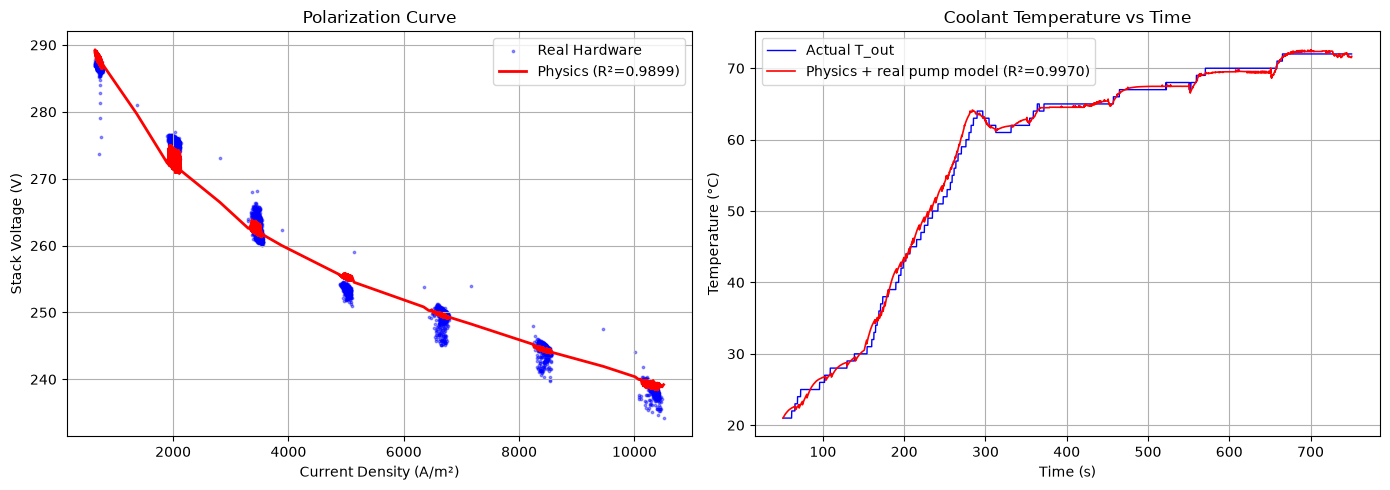

In [4]:
# ==============================================================================
# CELL 3: MULTI-CYCLE PARAMETER IDENTIFICATION (CONVECTIVE DIGITAL TWIN)
# Clean, final version. Includes: grounded coolant density and temperature-
# dependent specific heat, the empirical centrifugal pump flow model (real
# pump confirmed centrifugal, not positive-displacement, so flow can't be
# a fixed displacement x RPM), and bounds widened wherever prior runs showed
# parameters pinning at stale walls. Membrane hydration lag and double-layer
# capacitance lag were both built, tested, and ruled out with real evidence
# (membrane: tau 0.2-0.5s, too fast to matter; double-layer: C_dl pinned at
# its floor in a decoupled test, no-lag consistently beat with-lag), so
# neither is included here. This is the settled architecture going forward.
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.metrics import r2_score
import joblib

# ── 0. GROUNDED PHYSICAL CONSTANTS ───────────────────────────────────────────
COOLANT_DENSITY = 1065.0  # kg/m^3 — real FC stack coolant spec (was 1000.0,
                           # plain water; this now matches the same 1.065
                           # figure already used in CSV ingestion)

# Coolant specific heat, interpolated from the real spec table (was a fixed
# 3450 J/kg-K constant; actual value varies ~3230-3600 J/kg-K across the
# stack's real 20-90C operating range).
_CP_TABLE_TEMP_C = np.array([-30, -20, -10, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])
_CP_TABLE_KJ     = np.array([3.23, 3.25, 3.28, 3.3, 3.32, 3.38, 3.42,
                              3.46, 3.49, 3.51, 3.55, 3.58, 3.6])

def get_cp_coolant(T_kelvin):
    T_C = T_kelvin - 273.15
    return np.interp(T_C, _CP_TABLE_TEMP_C, _CP_TABLE_KJ) * 1000.0

# Empirical pump flow model. The physical coolant pump is centrifugal, not
# positive-displacement, confirmed directly with the lab. That means flow
# rate is NOT a fixed displacement x RPM (the old pump_disp assumption was
# never the right equation shape for this pump type). Coefficients below
# were fit by back-calculating real effective mass flow from energy-balance
# data (Q_conv / (cp * delta_T)), filtered to delta_T >= 5K to avoid the
# divide-by-zero instability near delta_T = 0, then regressed against real
# wp_rps and bypass_flow. Validated at R^2=0.9433 against real filtered data.
PUMP_COEF_WP   = 0.035344
PUMP_COEF_BP   = 0.3025
PUMP_INTERCEPT = -0.1364

def estimate_mdot(wp_rps, bypass_flow):
    """Empirical mass flow, kg/s. Clipped at a small positive floor since the
    fitted intercept is slightly negative and this was only validated within
    the wp_rps=10-35 range it was trained on."""
    m = PUMP_COEF_WP * wp_rps + PUMP_COEF_BP * bypass_flow + PUMP_INTERCEPT
    return max(m, 1e-3)


# ── 1. PHYSICAL BOUNDARY LIMITS (8 PARAMETERS) ────────────────────────────────
# Every bound below marked "widened" was previously pinned at a stale wall in
# earlier testing (confirmed via multi-start + isolated bound-relaxation
# checks) and has since settled at a real interior value once given room.
PHYSICAL_BOUNDS = np.array([
    [1e-4, 0.05],       # 0: i_n
    [1e-11, 1e-2],      # 1: i_0 — ceiling widened (was 1e-3, pinned there)
    [0.1, 15.0],        # 2: alpha — floor widened (was 0.5, confirmed real ~0.47)
    [0.1, 10.0],        # 3: k_lambda
    [1e-4, 5.0],        # 4: m_trans — ceiling widened (was 1.0, confirmed real ~2.1-2.2)
    [1e-8, 1e-2],       # 5: n_growth — both bounds widened (was 1e-6 to 1e-3, pinned at floor)
    [1e-8, 0.5],        # 6: k_dry — floor widened (was 1e-6, pinned there)
    [10.0, 50000.0]     # 7: hA — ceiling widened (was 10000.0, pinned there
                        #    once coolant properties were corrected)
])


# ── 2. MATHEMATICAL SPACE CONVERSION MAPPERS ─────────────────────────────────
def to_physical(norm_params):
    low = PHYSICAL_BOUNDS[:, 0]
    high = PHYSICAL_BOUNDS[:, 1]
    phys = low + norm_params * (high - low)
    log_low, log_high = np.log10(low[1]), np.log10(high[1])
    phys[1] = 10 ** (log_low + norm_params[1] * (log_high - log_low))
    return phys

def to_normalized(phys_params):
    low = PHYSICAL_BOUNDS[:, 0]
    high = PHYSICAL_BOUNDS[:, 1]
    norm = (phys_params - low) / (high - low)
    log_low, log_high = np.log10(low[1]), np.log10(high[1])
    norm[1] = (np.log10(phys_params[1]) - log_low) / (log_high - log_low)
    return np.clip(norm, 0.0, 1.0)


# ── 3. CORE TRANSIENT ACTIVATION-CORRECTED VOLTAGE LOOP ───────────────────────
def predict_voltage_loop(params, df_target, dt_target, t_start_target, return_coolant_split=False):
    hA = params[7]
    l_base = calculate_lambda_base(LAB_RH)
    T_stack_curr = t_start_target

    i_arr   = df_target['current_density'].values
    bp_arr  = df_target['bypass_flow'].values
    wp_arr  = df_target['wp_rps'].values
    h2_arr  = df_target['h2_p'].values
    air_arr = df_target['air_p'].values
    T_inlet = df_target['T_in_K'].values

    V_pred      = np.zeros(len(i_arr))
    T_stack_out = np.zeros(len(i_arr))
    T_out_out   = np.zeros(len(i_arr))

    T_ref = 353.15
    E_act = 40000.0
    R_gas = 8.314

    for k in range(len(i_arr)):
        current_params = params[0:7].copy()

        temp_factor = np.exp((-E_act / R_gas) * ((1.0 / T_stack_curr) - (1.0 / T_ref)))
        current_params[1] = params[1] * temp_factor

        k_lambda = current_params[3]
        k_dry    = current_params[6]
        l_steady_state = l_base + (k_lambda * (i_arr[k] / 12000.0)) - (k_dry * (T_stack_curr - 353.15))
        l_steady_state = np.clip(l_steady_state, 0.5, 14.0)

        T_C   = T_stack_curr - 273.15
        P_h2o = (10 ** (8.07131 - (1730.63 / (233.426 + T_C)))) * 133.322
        P_h2o = np.minimum(P_h2o, air_arr[k] * 0.9)

        V_val = cell_voltage(i_arr[k], T_stack_curr, h2_arr[k], air_arr[k], P_h2o, current_params, l_steady_state)

        cp_coolant_now = get_cp_coolant(T_inlet[k])
        m_dot = estimate_mdot(wp_arr[k], bp_arr[k])
        C_coolant = np.maximum(m_dot * cp_coolant_now, 1e-3)
        Q_conv = hA * (T_stack_curr - T_inlet[k])

        Q_gen = (i_arr[k] * Area) * (E_th - (V_val / N_cells)) * N_cells

        dT_stack = (Q_gen - Q_conv) * dt_target / (M_stack * Cp_stack)
        T_stack_curr += dT_stack

        T_fluid_out = T_inlet[k] + (Q_conv / C_coolant)

        V_pred[k]      = V_val
        T_stack_out[k] = T_stack_curr
        T_out_out[k]   = T_fluid_out

    if return_coolant_split:
        return V_pred, T_stack_out, T_out_out
    else:
        return V_pred, T_out_out


# ── 4. OBJECTIVE FUNCTIONS (JOINT MULTI-CYCLE EVALUATOR) ─────────────────────
def objective_multi(norm_params, dfs, dts, t_starts):
    phys_params = to_physical(norm_params)

    total_v_sse = 0.0
    total_tout_sse = 0.0
    total_n = 0

    for df, dt, t_start in zip(dfs, dts, t_starts):
        V_sim, _, T_out_sim = predict_voltage_loop(phys_params, df, dt, t_start,
                                                     return_coolant_split=True)

        if not np.all(np.isfinite(V_sim)) or not np.all(np.isfinite(T_out_sim)):
            return 1e10

        total_v_sse    += np.sum((V_sim - df['cell_voltage'].values)**2)
        total_tout_sse += np.sum((T_out_sim - df['T_out_K'].values)**2)
        total_n        += len(df)

    rmse_v = np.sqrt(total_v_sse / total_n)
    rmse_tout = np.sqrt(total_tout_sse / total_n)

    return (12.0 * rmse_v) + (2.0 * rmse_tout)


# ── 5. EXECUTE OPTIMIZATION ──────────────────────────────────────────────────
dfs_train      = [df_id, df_ramp, df_noisy, df_warm, df_extra]
dts_train      = [0.1, 0.1, 0.1, 0.1, 0.1]
t_starts_train = [T_IN_GLOBAL_ID, T_IN_GLOBAL_RAMP, T_IN_GLOBAL_NOISY, T_IN_GLOBAL_WARM, T_IN_GLOBAL_EXTRA]
training_names = ['NEDC', 'Ramp', 'Hysteresis', 'Warm', 'Extra']

# Seeded at the last confirmed-clean solved values (all 8 params landed
# interior, none pinned, this exact configuration), so convergence should be
# fast, consistent with the ~94 iterations that combination took last time.
BALANCED_SEEDS = [0.002507, 1.830294e-03, 0.4692, 1.8797, 2.159225,
                  9.996584e-07, 1.587911e-06, 3134.66]
INITIAL_NORM_GUESS = to_normalized(np.array(BALANCED_SEEDS))
NORM_BOUNDS = [(0.0, 1.0)] * 8

iteration_count = [0]
def progress_callback(xk):
    iteration_count[0] += 1
    if iteration_count[0] % 50 == 0:
        current_obj = objective_multi(xk, dfs_train, dts_train, t_starts_train)
        print(f"  ...iteration {iteration_count[0]}, objective={current_obj:.4f}")

print("Identifying Parameters (clean architecture: centrifugal pump model, "
      "grounded coolant properties, no transient lag terms)...")
res = minimize(objective_multi, INITIAL_NORM_GUESS,
               args=(dfs_train, dts_train, t_starts_train),
               method='L-BFGS-B', bounds=NORM_BOUNDS,
               callback=progress_callback,
               options={'maxiter': 1000, 'ftol': 1e-9, 'gtol': 1e-7})

SOLVED_PARAMS = to_physical(res.x)

print(f"\nOptimizer diagnostics:")
print(f"  Success        : {res.success}")
print(f"  Message        : {res.message}")
print(f"  Iterations     : {res.nit}")
print(f"  Final objective: {res.fun:.6f}")

print(f"\n{'='*50}")
print(f"PHYSICS-ONLY MULTI-CYCLE BASELINE:")
print(f"  Solved i_n       : {SOLVED_PARAMS[0]:.6f}")
print(f"  Solved i_0       : {SOLVED_PARAMS[1]:.6e}  (bound [1e-11, 1e-2])")
print(f"  Solved alpha     : {SOLVED_PARAMS[2]:.4f}  (bound [0.1, 15.0])")
print(f"  Solved k_lambda  : {SOLVED_PARAMS[3]:.4f}")
print(f"  Solved m_trans   : {SOLVED_PARAMS[4]:.6f}  (bound [1e-4, 5.0])")
print(f"  Solved n_growth  : {SOLVED_PARAMS[5]:.6e}  (bound [1e-8, 1e-2])")
print(f"  Solved k_dry     : {SOLVED_PARAMS[6]:.6e}  (bound [1e-8, 0.5])")
print(f"  Solved hA        : {SOLVED_PARAMS[7]:.2f}  (bound [10, 50000])")
print(f"  Full Solved Params: {SOLVED_PARAMS}")
print(f"{'='*50}\n")

print("Per-cycle training fit:")
for name, df, dt, t_start in zip(training_names, dfs_train, dts_train, t_starts_train):
    V_tr, _ = predict_voltage_loop(SOLVED_PARAMS, df, dt, t_start)
    r2_v_tr = r2_score(df['cell_voltage'], V_tr)
    rmse_v_tr = np.sqrt(np.mean((V_tr - df['cell_voltage'].values)**2))
    print(f"  {name:<15}: R² = {r2_v_tr:.4f} | RMSE = {rmse_v_tr:.4f} V")


# ── 6. VERIFICATION ────────────────────────────────────────────────────────────
V_ver_phys, T_stack_ver, T_ver_phys = predict_voltage_loop(
    SOLVED_PARAMS, df_ver, dt_ver, T_IN_GLOBAL_VER, return_coolant_split=True)

r2_phys = r2_score(df_ver['cell_voltage'], V_ver_phys)
rmse_phys = np.sqrt(np.mean((V_ver_phys - df_ver['cell_voltage'].values)**2))
r2_temp = r2_score(df_ver['T_out_K'], T_ver_phys)
rmse_temp = np.sqrt(np.mean((T_ver_phys - df_ver['T_out_K'].values)**2))

print(f"\n{'='*50}")
print(f"VERIFICATION SET — CORE SUBSYSTEM VALIDITY:")
print(f"  Voltage : R²={r2_phys:.4f} | RMSE={rmse_phys:.4f} V")
print(f"  T_out   : R²={r2_temp:.4f}  | RMSE={rmse_temp:.4f} K")
print(f"{'='*50}\n")


# ── 7. PLOTS ──────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sort_idx = np.argsort(df_ver['current_density'].values)
ax1.scatter(df_ver['current_density'], df_ver['cell_voltage'], color='blue', s=3, alpha=0.4, label='Real Hardware')
ax1.plot(df_ver['current_density'].values[sort_idx], V_ver_phys[sort_idx],
         color='red', linewidth=2, label=f'Physics (R²={r2_phys:.4f})')
ax1.set_title('Polarization Curve')
ax1.set_xlabel('Current Density (A/m²)')
ax1.set_ylabel('Stack Voltage (V)')
ax1.legend(); ax1.grid(True)

time = df_ver['time'].values
ax2.plot(time, df_ver['T_out_K'].values - 273.15, color='blue', linewidth=1.0, label='Actual T_out')
ax2.plot(time, T_ver_phys - 273.15, color='red', linewidth=1.2, label=f'Physics + real pump model (R²={r2_temp:.4f})')
ax2.set_title('Coolant Temperature vs Time')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Temperature (°C)')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()


## Cell 4 — REMOVED (open-loop SVR)

The open-loop SVR from `Polished_Stack_Model.ipynb` has been **removed**.

There is now **one SVR** in this architecture, trained in Cell 11 on residuals from the fully autonomous pipeline.

**Final architecture:** `V_final = Physics(ECU_inputs) + SVR_retrained`

Integrating ML ECU for Current (I)

Current ECU training samples: 34540 across 5 cycles
Current Random Forest trained.

Current ECU — Baseline Verification:
  R²   : 0.9996
  RMSE : 66.79 A/m²

RESULTS SUMMARY (physics only, no SVR):
  Model                                       R²       RMSE
  --------------------------------------------------
  Physics only (open-loop)                0.9899   1.6101 V
  Physics + ECU current (no SVR)          0.9893   1.6583 V
  Note: SVR correction deferred to Cell 11 (single retrained SVR)


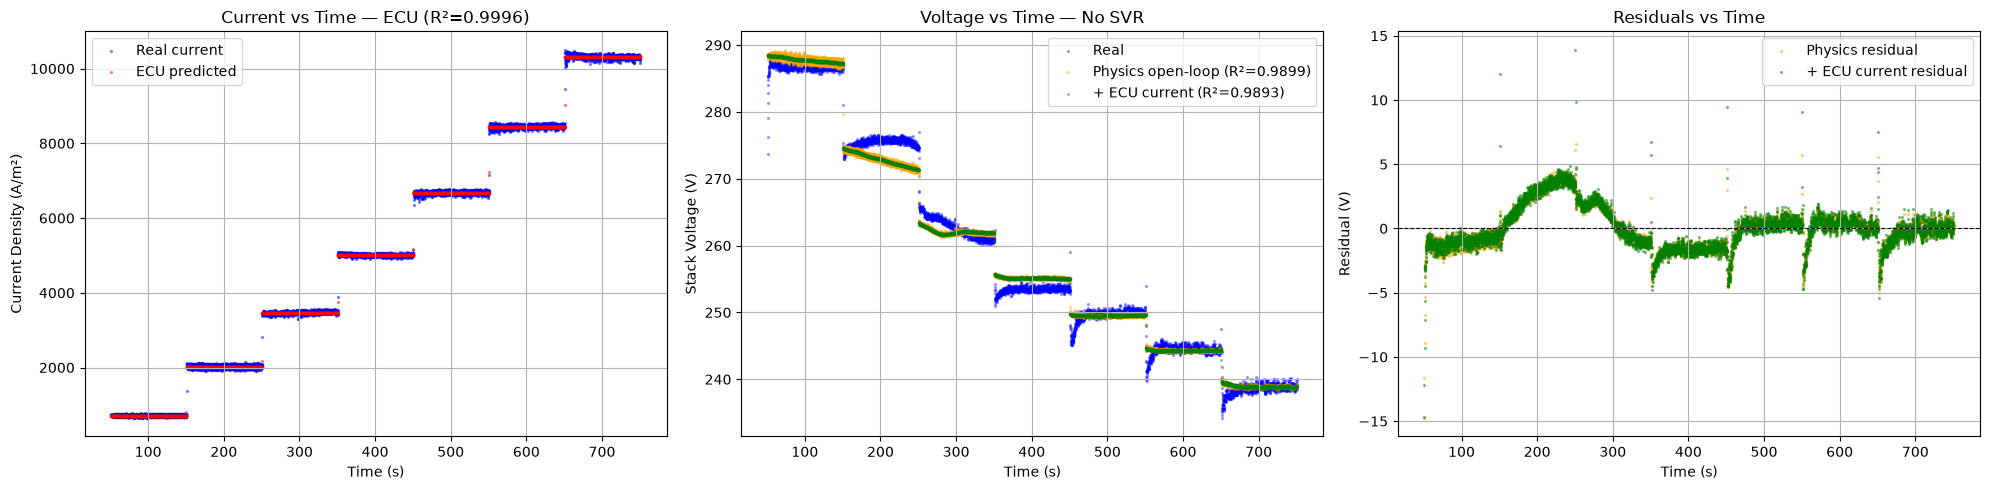


Current ECU saved.


In [5]:
# ============================================================
# CELL 5: ML ECU — CURRENT SUB-MODEL
# ============================================================
from sklearn.ensemble import RandomForestRegressor
import joblib

def build_ecu_features(df):
    power  = df['power_request'].values
    slope  = np.diff(power, prepend=power[0])
    t_init = np.full(len(df), df['T_in_K'].values[0])
    return np.column_stack([power, slope, t_init])

X_train_ecu = np.vstack([build_ecu_features(df_id),
                          build_ecu_features(df_ramp),
                          build_ecu_features(df_noisy),
                          build_ecu_features(df_warm),
                          build_ecu_features(df_extra)])

y_train_ecu = np.concatenate([df_id['current_density'].values,
                               df_ramp['current_density'].values,
                               df_noisy['current_density'].values,
                               df_warm['current_density'].values,
                               df_extra['current_density'].values])

print(f"Current ECU training samples: {len(y_train_ecu)} across 5 cycles")
ecu_current = RandomForestRegressor(n_estimators=100, max_depth=18, random_state=42, n_jobs=-1)
ecu_current.fit(X_train_ecu, y_train_ecu)
print("Current Random Forest trained.")

X_ver_ecu    = build_ecu_features(df_ver)
current_pred = ecu_current.predict(X_ver_ecu)
ecu_r2   = r2_score(df_ver['current_density'], current_pred)
ecu_rmse = np.sqrt(np.mean((current_pred - df_ver['current_density'].values)**2))
print(f"\nCurrent ECU — Baseline Verification:")
print(f"  R²   : {ecu_r2:.4f}")
print(f"  RMSE : {ecu_rmse:.2f} A/m²")

# Physics with ECU current only (no SVR — intermediate diagnostic)
df_ver_cl5 = df_ver.copy()
df_ver_cl5['current_density'] = current_pred
V_cl5_phys, _ = predict_voltage_loop(SOLVED_PARAMS, df_ver_cl5, dt_ver, T_IN_GLOBAL_VER)
r2_cl5_phys   = r2_score(df_ver['cell_voltage'], V_cl5_phys)
rmse_cl5_phys = np.sqrt(np.mean((V_cl5_phys - df_ver['cell_voltage'].values)**2))

print(f"\n{'='*52}")
print(f"RESULTS SUMMARY (physics only, no SVR):")
print(f"  {'Model':<38} {'R²':>7}  {'RMSE':>9}")
print(f"  {'-'*50}")
print(f"  {'Physics only (open-loop)':<38} {r2_phys:>7.4f}  {rmse_phys:>7.4f} V")
print(f"  {'Physics + ECU current (no SVR)':<38} {r2_cl5_phys:>7.4f}  {rmse_cl5_phys:>7.4f} V")
print(f"{'='*52}")
print("  Note: SVR correction deferred to Cell 11 (single retrained SVR)")

# Plots
time = df_ver['time'].values; i_real = df_ver['current_density'].values; V_real = df_ver['cell_voltage'].values
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].scatter(time, i_real, color='blue', s=2, alpha=0.4, label='Real current')
axes[0].scatter(time, current_pred, color='red', s=2, alpha=0.4, label='ECU predicted')
axes[0].set_title(f'Current vs Time — ECU (R²={ecu_r2:.4f})')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Current Density (A/m²)'); axes[0].legend(); axes[0].grid(True)
axes[1].scatter(time, V_real, color='blue', s=2, alpha=0.3, label='Real')
axes[1].scatter(time, V_ver_phys, color='orange', s=2, alpha=0.3, label=f'Physics open-loop (R²={r2_phys:.4f})')
axes[1].scatter(time, V_cl5_phys, color='green', s=2, alpha=0.3, label=f'+ ECU current (R²={r2_cl5_phys:.4f})')
axes[1].set_title('Voltage vs Time — No SVR'); axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Stack Voltage (V)'); axes[1].legend(); axes[1].grid(True)
axes[2].scatter(time, V_real - V_ver_phys, color='orange', s=2, alpha=0.4, label='Physics residual')
axes[2].scatter(time, V_real - V_cl5_phys, color='green', s=2, alpha=0.4, label='+ ECU current residual')
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[2].set_title('Residuals vs Time'); axes[2].set_xlabel('Time (s)'); axes[2].set_ylabel('Residual (V)')
axes[2].legend(); axes[2].grid(True)
plt.tight_layout(); plt.show()

joblib.dump(ecu_current, 'ecu_current_model.pkl', compress = 3)
print("\nCurrent ECU saved.")

Integrating ML ECU for H2 Pressure (II)

In [6]:
# ============================================================
# CELL 6: H2 PRESSURE — LINEAR MODEL
# ============================================================
from sklearn.linear_model import LinearRegression

def smooth_signal(arr, window=30):
    return pd.Series(arr).rolling(window=window, center=True, min_periods=1).mean().values

power_train = np.concatenate([df_id['power_request'].values,
                               df_ramp['power_request'].values,
                               df_noisy['power_request'].values,
                               df_warm['power_request'].values,
                               df_extra['power_request'].values]).reshape(-1, 1)

h2_train_smooth = np.concatenate([smooth_signal(df_id['h2_p'].values),
                                   smooth_signal(df_ramp['h2_p'].values),
                                   smooth_signal(df_noisy['h2_p'].values),
                                   smooth_signal(df_warm['h2_p'].values),
                                   smooth_signal(df_extra['h2_p'].values)])
h2_regressor = LinearRegression()
h2_regressor.fit(power_train, h2_train_smooth)
print(f"H2 linear model: slope={h2_regressor.coef_[0]:.6f} Pa/W, intercept={h2_regressor.intercept_:.0f} Pa")

power_ver     = df_ver['power_request'].values.reshape(-1, 1)
h2_pred       = h2_regressor.predict(power_ver)
h2_ver_smooth = smooth_signal(df_ver['h2_p'].values, window=30)
h2_r2   = r2_score(h2_ver_smooth, h2_pred)
h2_rmse = np.sqrt(np.mean((h2_pred - h2_ver_smooth)**2))
print(f"H2 linear model — Baseline (vs smoothed): R²={h2_r2:.4f} | RMSE={h2_rmse:.2f} Pa")

# Physics with ECU current + H2 (no SVR)
df_ver_cl6 = df_ver_cl5.copy()
df_ver_cl6['h2_p'] = h2_pred
V_cl6_phys, _ = predict_voltage_loop(SOLVED_PARAMS, df_ver_cl6, dt_ver, T_IN_GLOBAL_VER)
r2_cl6_phys   = r2_score(df_ver['cell_voltage'], V_cl6_phys)
print(f"\nPhysics + ECU current + H2 (no SVR): R²={r2_cl6_phys:.4f}")

joblib.dump(h2_regressor, 'h2_linear_model.pkl', compress = 3)
print("H2 linear model saved.")

H2 linear model: slope=-3.105739 Pa/W, intercept=1661041 Pa
H2 linear model — Baseline (vs smoothed): R²=-3.3289 | RMSE=104651.40 Pa

Physics + ECU current + H2 (no SVR): R²=0.9891
H2 linear model saved.


Integrating ML ECU for Air Intake Pressure (III)

In [7]:
# ============================================================
# CELL 7: ML ECU — AIR PRESSURE SUB-MODEL
# ============================================================
def build_ecu_features_air(df):
    power  = df['power_request'].values
    slope  = np.diff(power, prepend=power[0])
    t_init = np.full(len(df), df['T_in_K'].values[0])
    return np.column_stack([power, slope, t_init])

X_train_air = np.vstack([build_ecu_features_air(df_id),
                          build_ecu_features_air(df_ramp),
                          build_ecu_features_air(df_noisy),
                          build_ecu_features_air(df_warm),
                          build_ecu_features_air(df_extra)])

y_train_air = np.concatenate([smooth_signal(df_id['air_p'].values),
                               smooth_signal(df_ramp['air_p'].values),
                               smooth_signal(df_noisy['air_p'].values),
                               smooth_signal(df_warm['air_p'].values),
                               smooth_signal(df_extra['air_p'].values)])

ecu_air = RandomForestRegressor(n_estimators=100, max_depth=18,random_state=42, n_jobs=-1)
ecu_air.fit(X_train_air, y_train_air)
print("Air pressure Random Forest trained.")

X_ver_air      = build_ecu_features_air(df_ver)
air_pred       = ecu_air.predict(X_ver_air)
air_ver_smooth = smooth_signal(df_ver['air_p'].values, window=30)
air_r2   = r2_score(air_ver_smooth, air_pred)
air_rmse = np.sqrt(np.mean((air_pred - air_ver_smooth)**2))
print(f"Air pressure ECU — Baseline (vs smoothed): R²={air_r2:.4f} | RMSE={air_rmse:.0f} Pa")

# Physics with ECU current + H2 + air (no SVR)
df_ver_cl7 = df_ver_cl6.copy()
df_ver_cl7['air_p'] = air_pred
V_cl7_phys, _ = predict_voltage_loop(SOLVED_PARAMS, df_ver_cl7, dt_ver, T_IN_GLOBAL_VER)
r2_cl7_phys   = r2_score(df_ver['cell_voltage'], V_cl7_phys)
print(f"Physics + ECU current + H2 + air (no SVR): R²={r2_cl7_phys:.4f}")

joblib.dump(ecu_air, 'ecu_air_model.pkl', compress = 3)
print("Air pressure ECU saved.")

Air pressure Random Forest trained.
Air pressure ECU — Baseline (vs smoothed): R²=0.9929 | RMSE=2232 Pa
Physics + ECU current + H2 + air (no SVR): R²=0.9889
Air pressure ECU saved.


Integrating ML ECU for Bypass Flow Rate

In [8]:
# ============================================================
# CELL 8: ML ECU — BYPASS FLOW SUB-MODEL
# ============================================================
def build_ecu_features_bp(df):
    power  = df['power_request'].values
    slope  = np.diff(power, prepend=power[0])
    t_init = np.full(len(df), df['T_in_K'].values[0])
    return np.column_stack([power, slope, t_init])

X_train_bp = np.vstack([build_ecu_features_bp(df_id),
                         build_ecu_features_bp(df_ramp),
                         build_ecu_features_bp(df_noisy),
                         build_ecu_features_bp(df_warm),
                         build_ecu_features_bp(df_extra)])

y_train_bp = np.concatenate([smooth_signal(df_id['bypass_flow'].values),
                              smooth_signal(df_ramp['bypass_flow'].values),
                              smooth_signal(df_noisy['bypass_flow'].values),
                              smooth_signal(df_warm['bypass_flow'].values),
                              smooth_signal(df_extra['bypass_flow'].values)])

ecu_bp = RandomForestRegressor(n_estimators=100, max_depth=18, random_state=42, n_jobs=-1)
ecu_bp.fit(X_train_bp, y_train_bp)
print("Bypass flow Random Forest trained.")

X_ver_bp      = build_ecu_features_bp(df_ver)
bp_pred       = ecu_bp.predict(X_ver_bp)
bp_ver_smooth = smooth_signal(df_ver['bypass_flow'].values, window=30)
bp_r2   = r2_score(bp_ver_smooth, bp_pred)
bp_rmse = np.sqrt(np.mean((bp_pred - bp_ver_smooth)**2)) 
print(f"Bypass flow ECU — Baseline (vs smoothed): R²={bp_r2:.4f} | RMSE={bp_rmse:.6f}")

# Physics with ECU current + H2 + air + bypass (no SVR)
df_ver_cl8 = df_ver_cl7.copy()
df_ver_cl8['bypass_flow'] = bp_pred
V_cl8_phys, _ = predict_voltage_loop(SOLVED_PARAMS, df_ver_cl8, dt_ver, T_IN_GLOBAL_VER)
r2_cl8_phys   = r2_score(df_ver['cell_voltage'], V_cl8_phys)
print(f"Physics + ECU current + H2 + air + bypass (no SVR): R²={r2_cl8_phys:.4f}")

joblib.dump(ecu_bp, 'ecu_bypass_model.pkl', compress = 3)
print("Bypass flow ECU saved.")

Bypass flow Random Forest trained.
Bypass flow ECU — Baseline (vs smoothed): R²=0.9920 | RMSE=0.016241
Physics + ECU current + H2 + air + bypass (no SVR): R²=0.9889
Bypass flow ECU saved.


Integrating ML ECU for Main Coolant Flow Rate (V)

In [9]:
# ============================================================
# CELL 9: ML ECU — COOLANT PUMP FLOW SUB-MODEL
# ============================================================
def build_ecu_features_wp(df):
    power  = df['power_request'].values
    slope  = np.diff(power, prepend=power[0])
    t_init = np.full(len(df), df['T_in_K'].values[0])
    return np.column_stack([power, slope, t_init])

X_train_wp = np.vstack([build_ecu_features_wp(df_id),
                         build_ecu_features_wp(df_ramp),
                         build_ecu_features_wp(df_noisy),
                         build_ecu_features_wp(df_warm),
                         build_ecu_features_wp(df_extra)])
y_train_wp = np.concatenate([smooth_signal(df_id['wp_rps'].values),
                              smooth_signal(df_ramp['wp_rps'].values),
                              smooth_signal(df_noisy['wp_rps'].values),
                              smooth_signal(df_warm['wp_rps'].values),
                              smooth_signal(df_extra['wp_rps'].values)])

ecu_wp = RandomForestRegressor(n_estimators=100, max_depth=18, random_state=42, n_jobs=-1)
ecu_wp.fit(X_train_wp, y_train_wp)
print("Coolant pump flow Random Forest trained.")

X_ver_wp      = build_ecu_features_wp(df_ver)
wp_pred       = ecu_wp.predict(X_ver_wp)
wp_ver_smooth = smooth_signal(df_ver['wp_rps'].values, window=30)
wp_r2   = r2_score(wp_ver_smooth, wp_pred)
wp_rmse = np.sqrt(np.mean((wp_pred - wp_ver_smooth)**2))
print(f"Coolant flow ECU — Baseline (vs smoothed): R²={wp_r2:.4f} | RMSE={wp_rmse:.6f} rps")

# Physics with all ECUs except thermal (no SVR)
df_ver_cl9 = df_ver_cl8.copy()
df_ver_cl9['wp_rps'] = wp_pred
V_cl9_phys, _ = predict_voltage_loop(SOLVED_PARAMS, df_ver_cl9, dt_ver, T_IN_GLOBAL_VER)
r2_cl9_phys   = r2_score(df_ver['cell_voltage'], V_cl9_phys)
print(f"Physics + all ECUs except thermal (no SVR): R²={r2_cl9_phys:.4f}")

joblib.dump(ecu_wp, 'ecu_coolant_model.pkl', compress = 3)
print("Coolant flow ECU saved.")

Coolant pump flow Random Forest trained.
Coolant flow ECU — Baseline (vs smoothed): R²=0.9933 | RMSE=0.527179 rps
Physics + all ECUs except thermal (no SVR): R²=0.9889
Coolant flow ECU saved.


Integrating H2 Consumtpion Model (VI)

H2 residual stats across training set:
  Mean  : 31.094 mg/s
  Std   : 24.182 mg/s
  Max   : 126.790 mg/s
  Min   : -139.585 mg/s
  Samples: 34540 across 4 cycles

H2 RF residual model trained.

Feature importances:
  faraday              : 0.0702
  current_density      : 0.0753
  power_request        : 0.0434
  slope_current        : 0.0610
  slope_power          : 0.0573
  air_p                : 0.6532
  T_in_K               : 0.0397

H2 CONSUMPTION MODEL — BASELINE VERIFICATION:
  Model                                         R²        RMSE
  ----------------------------------------------------------
  Faraday only                              0.9835   45.009 mg/s
  Faraday + RF residual                     0.9998    5.428 mg/s

Cumulative H2 over full cycle:
  Real              : 399.89 g
  Faraday + RF      : 399.66 g  (error: 0.22 g)
  Faraday only      : 374.65 g  (error: 25.23 g)

Per-cycle training fit:
  NEDC        : R²=0.9999 | RMSE=2.740 mg/s
  Ramp        : R²=0.9999 | RM

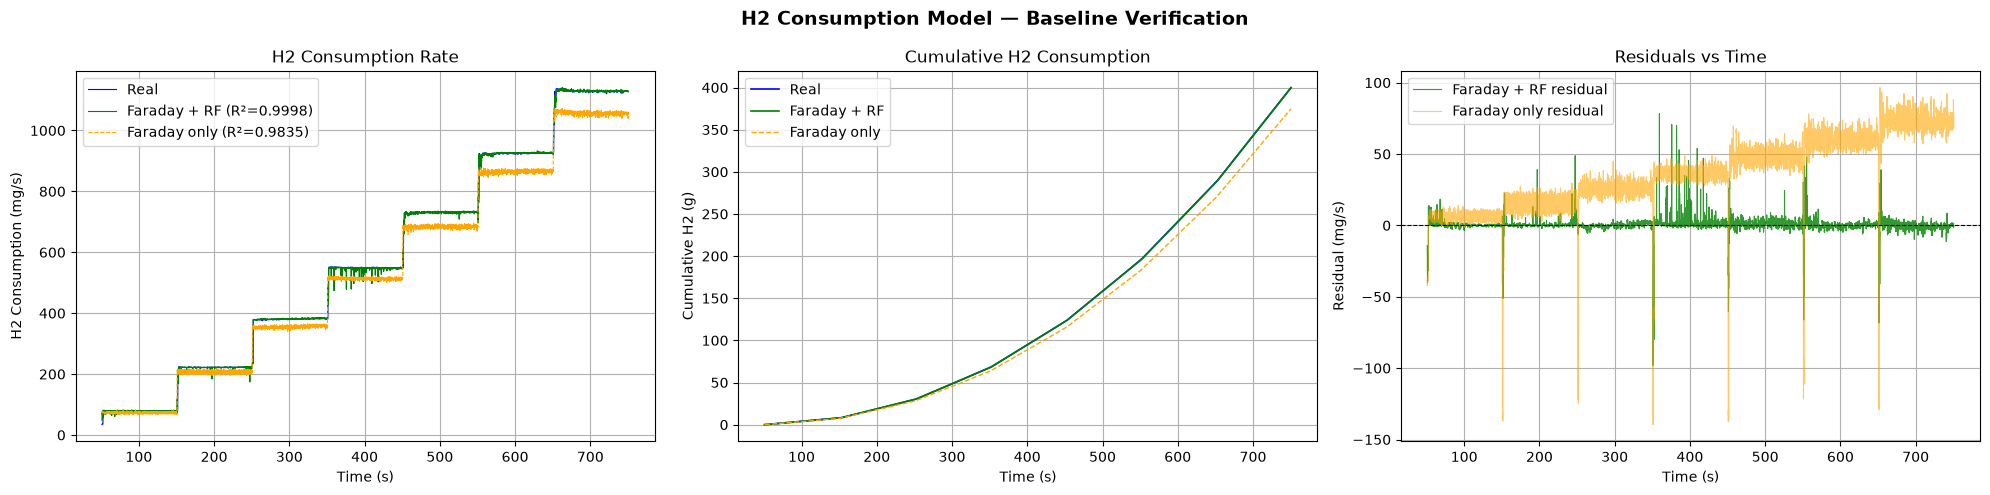


H2 RF residual model saved as ecu_h2_model.pkl
Note: at inference time, run faraday_h2(current_density) + ecu_h2.predict(features)


In [10]:
# ==============================================================================
# CELL 13: H2 CONSUMPTION MODEL (Faraday Physics + RF Residual)
# ==============================================================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import joblib

M_H2    = 2.016e-3  # kg/mol
F_const = 96485.0

# ── 1. FARADAY BASELINE FUNCTION ──────────────────────────────────────────────
def faraday_h2(current_density_arr):
    """Theoretical H2 consumption from electrochemistry (mg/s)."""
    return (current_density_arr * Area * N_cells * M_H2 / (2 * F_const)) * 1e6

# ── 2. FEATURE BUILDER ────────────────────────────────────────────────────────
def build_h2_features(df, faraday_arr):
    """
    Features for RF residual correction.
    Includes Faraday baseline, current transient rate, power, air pressure,
    and T_in as proxies for purge conditions and crossover losses.
    """
    slope_i    = np.diff(df['current_density'].values, prepend=df['current_density'].values[0])
    slope_p    = np.diff(df['power_request'].values,   prepend=df['power_request'].values[0])
    return np.column_stack([
        faraday_arr,                       # physics anchor
        df['current_density'].values,      # operating point
        df['power_request'].values,        # load demand
        slope_i,                           # current transient (purge trigger proxy)
        slope_p,                           # power transient
        df['air_p'].values,                # air pressure (stoichiometry proxy)
        df['T_in_K'].values,               # temperature (crossover loss proxy)
    ])

# ── 3. BUILD TRAINING ARRAYS ──────────────────────────────────────────────────
faraday_id    = faraday_h2(df_id['current_density'].values)
faraday_ramp  = faraday_h2(df_ramp['current_density'].values)
faraday_noisy = faraday_h2(df_noisy['current_density'].values)
faraday_warm  = faraday_h2(df_warm['current_density'].values)
faraday_extra = faraday_h2(df_extra['current_density'].values)

X_train_h2 = np.vstack([
    build_h2_features(df_id,    faraday_id),
    build_h2_features(df_ramp,  faraday_ramp),
    build_h2_features(df_noisy, faraday_noisy),
    build_h2_features(df_warm,  faraday_warm),
    build_h2_features(df_extra, faraday_extra),
])

# Target: residual delta above Faraday baseline
y_train_h2 = np.concatenate([
    df_id['H2_consumption'].values    - faraday_id,
    df_ramp['H2_consumption'].values  - faraday_ramp,
    df_noisy['H2_consumption'].values - faraday_noisy,
    df_warm['H2_consumption'].values  - faraday_warm,
    df_extra['H2_consumption'].values - faraday_extra
])

print(f"H2 residual stats across training set:")
print(f"  Mean  : {np.mean(y_train_h2):.3f} mg/s")
print(f"  Std   : {np.std(y_train_h2):.3f} mg/s")
print(f"  Max   : {np.max(y_train_h2):.3f} mg/s")
print(f"  Min   : {np.min(y_train_h2):.3f} mg/s")
print(f"  Samples: {len(y_train_h2)} across 4 cycles")

# ── 4. TRAIN RF ───────────────────────────────────────────────────────────────
ecu_h2 = RandomForestRegressor(n_estimators=100, max_depth=18,random_state=42, n_jobs=-1)
ecu_h2.fit(X_train_h2, y_train_h2)
print("\nH2 RF residual model trained.")

# Feature importance
feature_names = ['faraday', 'current_density', 'power_request',
                 'slope_current', 'slope_power', 'air_p', 'T_in_K']
print("\nFeature importances:")
for name, imp in zip(feature_names, ecu_h2.feature_importances_):
    print(f"  {name:<20} : {imp:.4f}")

# ── 5. VERIFY ON BASELINE ─────────────────────────────────────────────────────
faraday_ver  = faraday_h2(df_ver['current_density'].values)
X_ver_h2     = build_h2_features(df_ver, faraday_ver)
delta_pred   = ecu_h2.predict(X_ver_h2)
h2_pred_ver  = faraday_ver + delta_pred
h2_real_ver  = df_ver['H2_consumption'].values

h2_r2   = r2_score(h2_real_ver, h2_pred_ver)
h2_rmse = np.sqrt(np.mean((h2_pred_ver - h2_real_ver) ** 2))

# Faraday-only baseline for comparison
faraday_r2   = r2_score(h2_real_ver, faraday_ver)
faraday_rmse = np.sqrt(np.mean((faraday_ver - h2_real_ver) ** 2))

# Cumulative consumption over full cycle
h2_total_real   = np.sum(h2_real_ver)  * dt_ver / 1000  # g
h2_total_pred   = np.sum(h2_pred_ver)  * dt_ver / 1000  # g
h2_total_faraday= np.sum(faraday_ver)  * dt_ver / 1000  # g

print(f"\n{'='*60}")
print(f"H2 CONSUMPTION MODEL — BASELINE VERIFICATION:")
print(f"  {'Model':<40} {'R²':>7}  {'RMSE':>10}")
print(f"  {'-'*58}")
print(f"  {'Faraday only':<40} {faraday_r2:>7.4f}  {faraday_rmse:>7.3f} mg/s")
print(f"  {'Faraday + RF residual':<40} {h2_r2:>7.4f}  {h2_rmse:>7.3f} mg/s")
print(f"{'='*60}")
print(f"\nCumulative H2 over full cycle:")
print(f"  Real              : {h2_total_real:.2f} g")
print(f"  Faraday + RF      : {h2_total_pred:.2f} g  "
      f"(error: {abs(h2_total_pred-h2_total_real):.2f} g)")
print(f"  Faraday only      : {h2_total_faraday:.2f} g  "
      f"(error: {abs(h2_total_faraday-h2_total_real):.2f} g)")

# Per-cycle training fit
print(f"\nPer-cycle training fit:")
for name, df, faraday_tr in [('NEDC',       df_id,    faraday_id),
                               ('Ramp',       df_ramp,  faraday_ramp),
                               ('Hysteresis', df_noisy, faraday_noisy),
                               ('Warm',       df_warm,  faraday_warm)]:
    X_tr   = build_h2_features(df, faraday_tr)
    h2_tr  = faraday_tr + ecu_h2.predict(X_tr)
    r2_tr  = r2_score(df['H2_consumption'].values, h2_tr)
    rmse_tr= np.sqrt(np.mean((h2_tr - df['H2_consumption'].values)**2))
    print(f"  {name:<12}: R²={r2_tr:.4f} | RMSE={rmse_tr:.3f} mg/s")

# ── 6. PLOTS ──────────────────────────────────────────────────────────────────
time = df_ver['time'].values

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('H2 Consumption Model — Baseline Verification', fontsize=14, fontweight='bold')

# Rate plot
axes[0].plot(time, h2_real_ver,  color='blue',   linewidth=0.8, label='Real')
axes[0].plot(time, h2_pred_ver,  color='green',  linewidth=0.8,
             label=f'Faraday + RF (R²={h2_r2:.4f})')
axes[0].plot(time, faraday_ver,  color='orange', linewidth=0.8, linestyle='--',
             label=f'Faraday only (R²={faraday_r2:.4f})')
axes[0].set_title('H2 Consumption Rate')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('H2 Consumption (mg/s)')
axes[0].legend(); axes[0].grid(True)

# Cumulative consumption
axes[1].plot(time, np.cumsum(h2_real_ver)  * dt_ver / 1000,
             color='blue',   linewidth=1.2, label='Real')
axes[1].plot(time, np.cumsum(h2_pred_ver)  * dt_ver / 1000,
             color='green',  linewidth=1.2, label='Faraday + RF')
axes[1].plot(time, np.cumsum(faraday_ver)  * dt_ver / 1000,
             color='orange', linewidth=1.0, linestyle='--', label='Faraday only')
axes[1].set_title('Cumulative H2 Consumption')
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Cumulative H2 (g)')
axes[1].legend(); axes[1].grid(True)

# Residuals
axes[2].plot(time, h2_real_ver - h2_pred_ver,
             color='green',  linewidth=0.8, alpha=0.8, label='Faraday + RF residual')
axes[2].plot(time, h2_real_ver - faraday_ver,
             color='orange', linewidth=0.8, alpha=0.6, label='Faraday only residual')
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[2].set_title('Residuals vs Time')
axes[2].set_xlabel('Time (s)'); axes[2].set_ylabel('Residual (mg/s)')
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.show()

# ── 7. SAVE ───────────────────────────────────────────────────────────────────
joblib.dump(ecu_h2, 'ecu_h2_model.pkl', compress = 3)
print("\nH2 RF residual model saved as ecu_h2_model.pkl")
print("Note: at inference time, run faraday_h2(current_density) + ecu_h2.predict(features)")

Integrating Thermal Model for Inlet Coolant Temp (VII)

Fitting T_in thermal model...

Fitted Parameters:
  heat_gain        : 2.428827e-05
  cooling_base     : 2.442227e-04
  cooling_wp       : 1.468667e-03
  cooling_bp       : -4.078631e-02
  cooling_interact : 2.040846e-03

Per-cycle training fit:
  NEDC        : R²=0.8627 | RMSE=3.2294 K
  Ramp        : R²=0.9674 | RMSE=1.8722 K
  Hysteresis  : R²=0.9747 | RMSE=1.5515 K
  Warm        : R²=-0.1496 | RMSE=3.1542 K
  Extra       : R²=0.9776 | RMSE=1.6570 K

T_in — Baseline verification:
  R²   : 0.9776
  RMSE : 1.6570 K
  Predicted start : 21.00°C  (real: 21.00°C)

Training T_in residual model on 34,540 samples...

T_in — Physics vs. Hybrid (verification):
  Physics only        : R²=0.9776         | RMSE=1.6570 K
  Physics + Residual  : R²=0.9998  | RMSE=0.1401 K

FULLY AUTONOMOUS PHYSICS — PRE-SVR:
  Model                                               R²       RMSE
  ----------------------------------------------------------
  Physics open-loop                               0.9899   1.610

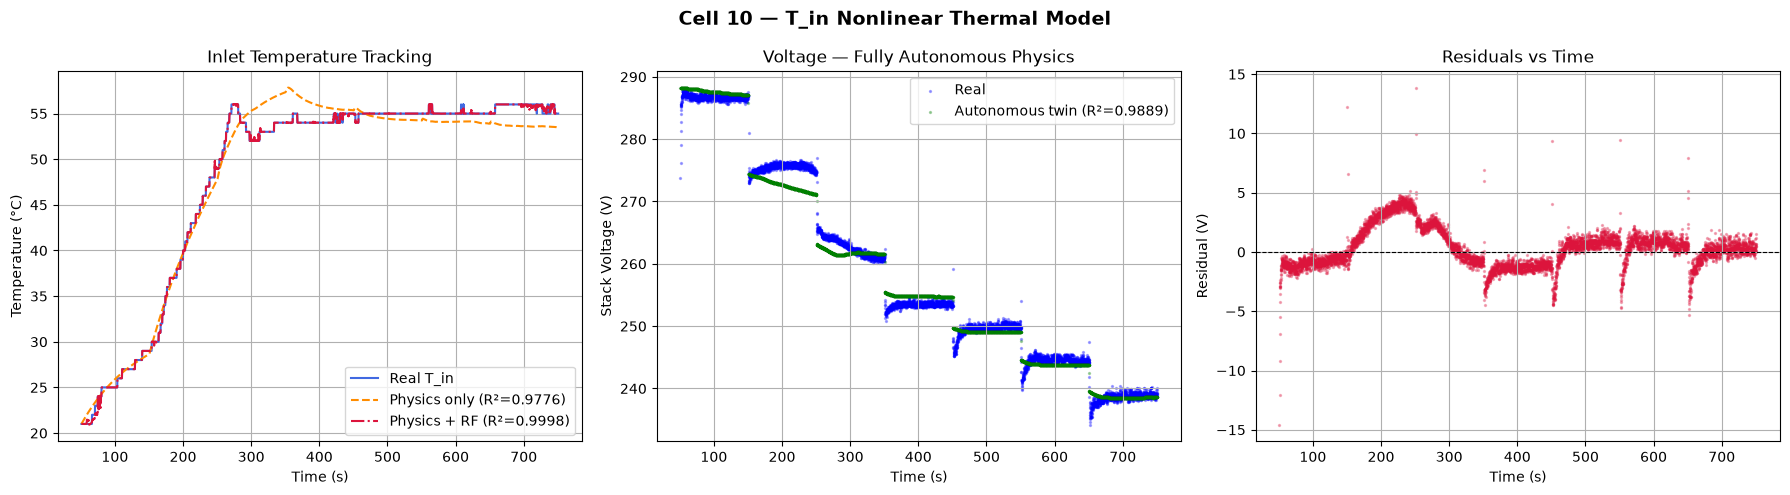

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

# ==============================================================================
# CELL 10: T_in THERMAL SUB-MODEL (Non-Linear Actuator State-Space)
# ==============================================================================

# ── 0. INDEX RESET (safety guard against Cell 2 filter gaps) ──────────────────
df_ver   = df_ver.reset_index(drop=True)
df_id    = df_id.reset_index(drop=True)
df_ramp  = df_ramp.reset_index(drop=True)
df_noisy = df_noisy.reset_index(drop=True)
df_warm  = df_warm.reset_index(drop=True)

# ── 1. THERMAL INTEGRATOR ─────────────────────────────────────────────────────
def predict_tin_actuator_dynamic_nonlinear(df, t_start, heat_gain, cooling_base,
                                            cooling_wp, cooling_bp, cooling_interact,
                                            fixed_dt=None, T_amb=295.15):
    power = df['power_request'].values
    wp    = df['wp_rps'].values
    bp    = df['bypass_flow'].values

    n  = len(power)
    T  = np.zeros(n)
    T[0] = t_start

    if fixed_dt is not None:
        dts = np.full(n - 1, fixed_dt)
    else:
        dts = np.diff(df['time'].values)

    for i in range(1, n):
        dt     = dts[i - 1]
        T_prev = T[i - 1]

        Q_heat = heat_gain * power[i - 1]

        k_cool = (cooling_base
                  + cooling_wp    * (wp[i - 1] ** 0.8)
                  + cooling_bp    *  bp[i - 1]
                  + cooling_interact * wp[i - 1] * bp[i - 1])

        if k_cool < 1e-6:
            k_cool = 1e-6

        T[i] = T_prev + (Q_heat - k_cool * (T_prev - T_amb)) * dt

    return T

# ── 2. OBJECTIVE ──────────────────────────────────────────────────────────────
def tin_objective_nonlinear(params):
    hg, cb, cwp, cbp, ci = params
    total_sse = 0.0
    for df, dt_val, t_start in [(df_id,    dt_id,    T_IN_GLOBAL_ID),
                                  (df_ramp,  dt_ramp,  T_IN_GLOBAL_RAMP),
                                  (df_noisy, dt_noisy, T_IN_GLOBAL_NOISY),
                                  (df_warm,  dt_warm,  T_IN_GLOBAL_WARM),
                                  (df_extra, dt_extra, T_IN_GLOBAL_EXTRA)]:
        T_pred = predict_tin_actuator_dynamic_nonlinear(
            df, t_start, hg, cb, cwp, cbp, ci, fixed_dt=dt_val)
        total_sse += np.sum((T_pred - df['T_in_K'].values) ** 2)
    return total_sse

# ── 3. OPTIMIZATION ───────────────────────────────────────────────────────────
print("Fitting T_in thermal model...")

res_tin = minimize(
    tin_objective_nonlinear,
    x0     = [1e-5, 1e-4, 1e-4, 0.01, 1e-4],
    method = 'L-BFGS-B',
    bounds = [(1e-7, 1e-4), (1e-6, 1e-2), (1e-6, 1e-2), (-0.5, 0.5), (1e-7, 1e-2)],
    options= {'maxiter': 2000, 'ftol': 1e-7}
)

HEAT_GAIN, COOLING_BASE, COOLING_WP, COOLING_BP, COOLING_INTERACT = res_tin.x

print(f"\nFitted Parameters:")
print(f"  heat_gain        : {HEAT_GAIN:.6e}")
print(f"  cooling_base     : {COOLING_BASE:.6e}")
print(f"  cooling_wp       : {COOLING_WP:.6e}")
print(f"  cooling_bp       : {COOLING_BP:.6e}")
print(f"  cooling_interact : {COOLING_INTERACT:.6e}")

# Per-cycle training fit
print(f"\nPer-cycle training fit:")
for name, df, dt_val, t_start in [('NEDC',       df_id,    dt_id,    T_IN_GLOBAL_ID),
                                    ('Ramp',       df_ramp,  dt_ramp,  T_IN_GLOBAL_RAMP),
                                    ('Hysteresis', df_noisy, dt_noisy, T_IN_GLOBAL_NOISY),
                                    ('Warm',       df_warm,  dt_warm,  T_IN_GLOBAL_WARM),
                                    ('Extra',      df_extra, dt_extra, T_IN_GLOBAL_EXTRA)]:
    T_pred = predict_tin_actuator_dynamic_nonlinear(
        df, t_start, HEAT_GAIN, COOLING_BASE, COOLING_WP, COOLING_BP, COOLING_INTERACT,
        fixed_dt=dt_val)
    r2   = r2_score(df['T_in_K'].values, T_pred)
    rmse = np.sqrt(np.mean((T_pred - df['T_in_K'].values) ** 2))
    print(f"  {name:<12}: R²={r2:.4f} | RMSE={rmse:.4f} K")

# ── 4. VERIFICATION ───────────────────────────────────────────────────────────
tin_pred_ver = predict_tin_actuator_dynamic_nonlinear(
    df_ver, T_IN_GLOBAL_VER,
    HEAT_GAIN, COOLING_BASE, COOLING_WP, COOLING_BP, COOLING_INTERACT,
    fixed_dt=dt_ver)

tin_r2   = r2_score(df_ver['T_in_K'].values, tin_pred_ver)
tin_rmse = np.sqrt(np.mean((tin_pred_ver - df_ver['T_in_K'].values) ** 2))

print(f"\nT_in — Baseline verification:")
print(f"  R²   : {tin_r2:.4f}")
print(f"  RMSE : {tin_rmse:.4f} K")
print(f"  Predicted start : {tin_pred_ver[0]-273.15:.2f}°C  "
      f"(real: {df_ver['T_in_K'].values[0]-273.15:.2f}°C)")

# ── 4.5. RESIDUAL ML CORRECTION LAYER ─────────────────────────────────────────
def build_tin_residual_features(df, T_physics_pred):
    """Features for the T_in residual model. Includes the physics estimate
    itself, since the residual model needs to know *where* the physics
    prediction currently sits in order to correct it, not just the raw
    drive-cycle inputs that fed the physics loop."""
    return np.column_stack([
        df['power_request'].values,
        df['wp_rps'].values,
        df['bypass_flow'].values,
        T_physics_pred,
    ])

# Build training features/targets across all 5 training cycles, same set
# used to fit the physics parameters above, so the residual model sees
# exactly the same operating range the physics was calibrated against.
X_tin_parts, y_tin_parts = [], []
for df, dt_val, t_start in [(df_id,    dt_id,    T_IN_GLOBAL_ID),
                              (df_ramp,  dt_ramp,  T_IN_GLOBAL_RAMP),
                              (df_noisy, dt_noisy, T_IN_GLOBAL_NOISY),
                              (df_warm,  dt_warm,  T_IN_GLOBAL_WARM),
                              (df_extra, dt_extra, T_IN_GLOBAL_EXTRA)]:
    T_phys = predict_tin_actuator_dynamic_nonlinear(
        df, t_start, HEAT_GAIN, COOLING_BASE, COOLING_WP, COOLING_BP,
        COOLING_INTERACT, fixed_dt=dt_val)
    residual = df['T_in_K'].values - T_phys
    X_tin_parts.append(build_tin_residual_features(df, T_phys))
    y_tin_parts.append(residual)

X_tin_train = np.vstack(X_tin_parts)
y_tin_train = np.concatenate(y_tin_parts)

print(f"\nTraining T_in residual model on {len(y_tin_train):,} samples...")

tin_residual_model = RandomForestRegressor(n_estimators=100, max_depth=18,random_state=42, n_jobs=-1)
tin_residual_model.fit(X_tin_train, y_tin_train)

# ── Apply to verification set ─────────────────────────────────────────────
X_tin_ver = build_tin_residual_features(df_ver, tin_pred_ver)
tin_residual_pred = tin_residual_model.predict(X_tin_ver)

tin_pred_ver_hybrid = tin_pred_ver + tin_residual_pred

tin_r2_hybrid   = r2_score(df_ver['T_in_K'].values, tin_pred_ver_hybrid)
tin_rmse_hybrid = np.sqrt(np.mean((tin_pred_ver_hybrid - df_ver['T_in_K'].values) ** 2))

print(f"\nT_in — Physics vs. Hybrid (verification):")
print(f"  {'Physics only':<20}: R²={tin_r2:.4f}         | RMSE={tin_rmse:.4f} K")
print(f"  {'Physics + Residual':<20}: R²={tin_r2_hybrid:.4f}  | RMSE={tin_rmse_hybrid:.4f} K")

# Save for deployment, matching the pkl pattern used for other ECUs
import joblib
joblib.dump(tin_residual_model,  'tin_residual_model.pkl', compress = 3)

# ── 5. BUILD AUTONOMOUS df_ver AND RUN PHYSICS ────────────────────────────────
df_ver_auto = df_ver.copy()
df_ver_auto['current_density'] = ecu_current.predict(build_ecu_features(df_ver))
df_ver_auto['h2_p']            = h2_regressor.predict(df_ver['power_request'].values.reshape(-1, 1))
df_ver_auto['air_p']           = ecu_air.predict(build_ecu_features_air(df_ver))
df_ver_auto['bypass_flow']     = ecu_bp.predict(build_ecu_features_bp(df_ver))
df_ver_auto['wp_rps']          = ecu_wp.predict(build_ecu_features_wp(df_ver))
df_ver_auto['T_in_K']          = tin_pred_ver_hybrid   # ← now using hybrid, not physics-only

# Physics co-solves voltage AND T_out
V_auto_phys, T_auto_phys = predict_voltage_loop(
    SOLVED_PARAMS, df_ver_auto, dt_ver, T_IN_GLOBAL_VER)

df_ver_auto['T_out_K'] = T_auto_phys

r2_auto_phys   = r2_score(df_ver['cell_voltage'], V_auto_phys)
rmse_auto_phys = np.sqrt(np.mean((V_auto_phys - df_ver['cell_voltage'].values) ** 2))

print(f"\n{'='*60}")
print(f"FULLY AUTONOMOUS PHYSICS — PRE-SVR:")
print(f"  {'Model':<46} {'R²':>7}  {'RMSE':>9}")
print(f"  {'-'*58}")
print(f"  {'Physics open-loop':<46} {r2_phys:>7.4f}  {rmse_phys:>7.4f} V")
print(f"  {'Fully autonomous (Nonlinear Thermal)':<46} {r2_auto_phys:>7.4f}  {rmse_auto_phys:>7.4f} V")
print(f"{'='*60}")
print(f"  >> Rerun Cell 11 (SVR retrain) after this cell.")

# ── 6. PLOTS ──────────────────────────────────────────────────────────────────
time = df_ver['time'].values
V_real = df_ver['cell_voltage'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Cell 10 — T_in Nonlinear Thermal Model', fontsize=14, fontweight='bold')

axes[0].plot(time, df_ver['T_in_K'].values - 273.15,
             color='royalblue', linewidth=1.5, label='Real T_in')
axes[0].plot(time, tin_pred_ver - 273.15,
             color='darkorange', linewidth=1.5, linestyle='--',
             label=f'Physics only (R²={tin_r2:.4f})')
axes[0].plot(time, tin_pred_ver_hybrid - 273.15,
             color='crimson', linewidth=1.5, linestyle='-.',
             label=f'Physics + RF (R²={tin_r2_hybrid:.4f})')
axes[0].set_title('Inlet Temperature Tracking')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Temperature (°C)')
axes[0].legend(); axes[0].grid(True)

axes[1].scatter(time, V_real,       color='blue',  s=2, alpha=0.3, label='Real')
axes[1].scatter(time, V_auto_phys,  color='green', s=2, alpha=0.3,
                label=f'Autonomous twin (R²={r2_auto_phys:.4f})')
axes[1].set_title('Voltage — Fully Autonomous Physics')
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Stack Voltage (V)')
axes[1].legend(); axes[1].grid(True)

axes[2].scatter(time, V_real - V_auto_phys, color='crimson', s=2, alpha=0.3)
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[2].set_title('Residuals vs Time')
axes[2].set_xlabel('Time (s)'); axes[2].set_ylabel('Residual (V)')
axes[2].grid(True)

plt.tight_layout()
plt.show()

SVR Residual Model Integration

Building autonomous training DataFrames...
Done.

Autonomous residual stats (all training cycles):
  Mean : -0.0182 V
  Std  : 2.5217 V
  Max  : 13.6794 V
  Min  : -15.2645 V

SVR training samples: 34540 across 5 cycles
Training SVR (single correction layer)...
SVR trained.

FINAL RESULTS — SINGLE SVR ARCHITECTURE:
  Model                                               R²       RMSE
  ------------------------------------------------------------
  Physics open-loop (no ECU, no SVR)              0.9899   1.6101 V
  Fully autonomous physics (no SVR)               0.9889   1.6906 V
  Fully autonomous + single retrained SVR         0.9936   1.2823 V

SVR correction: mean=0.6077V | std=1.2395V


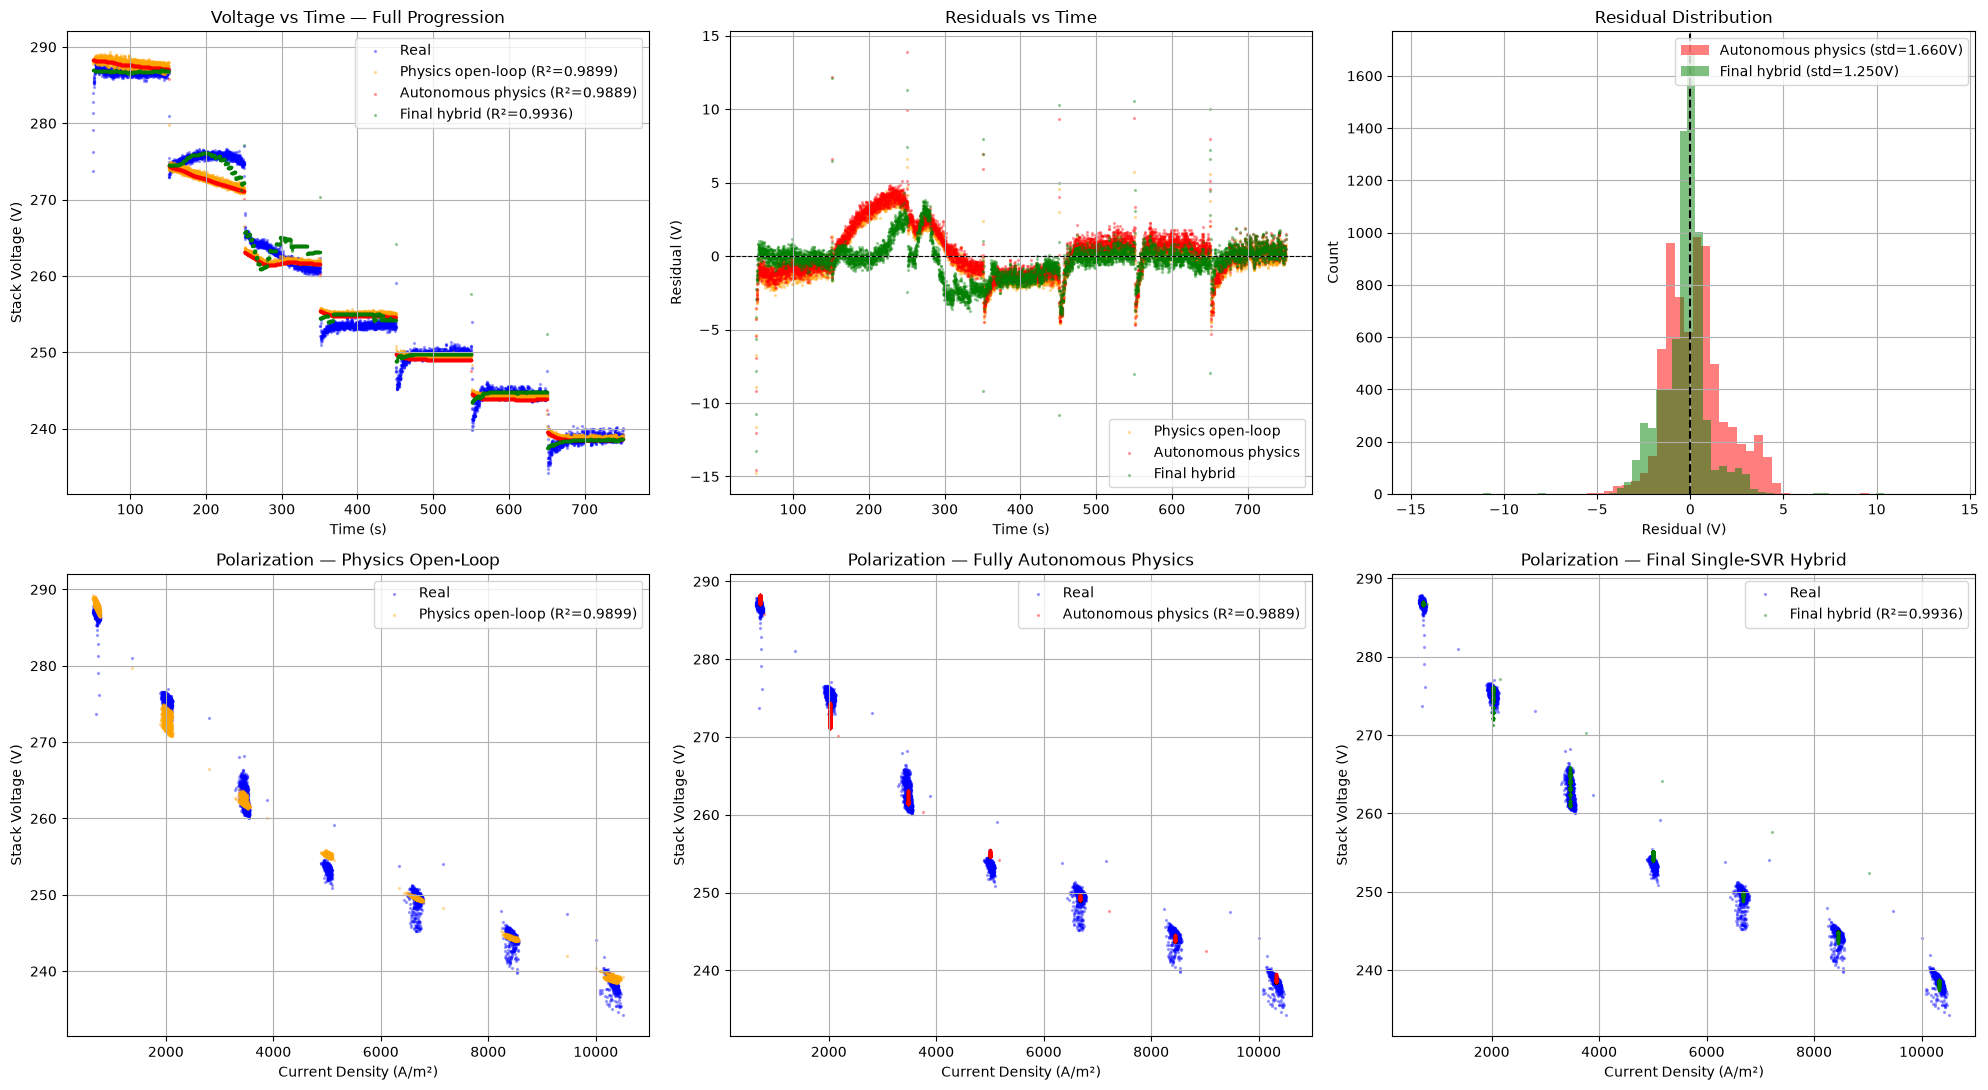

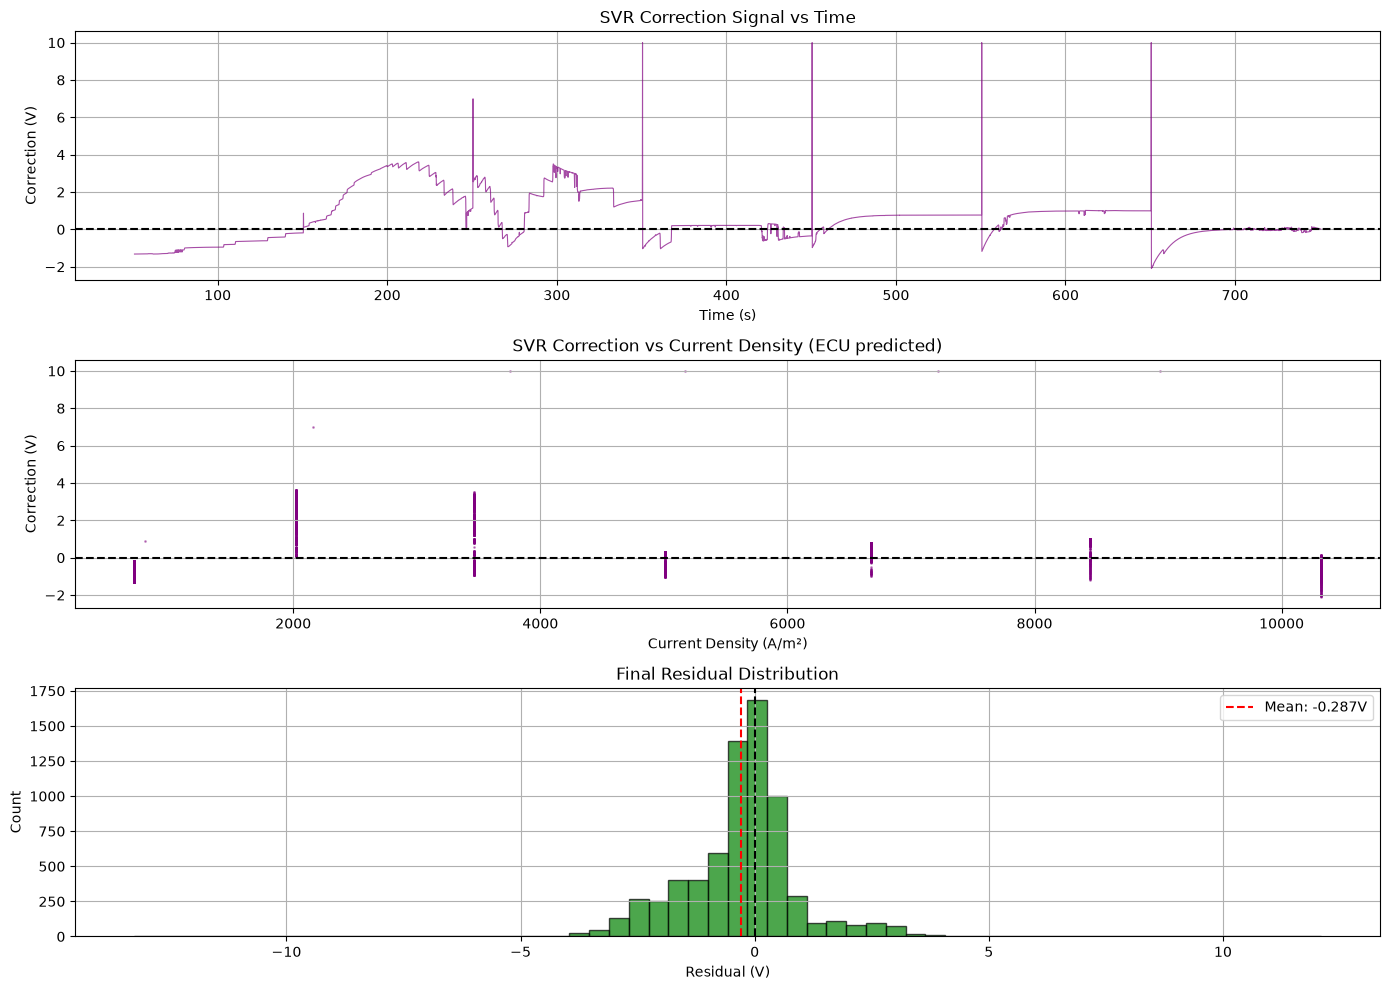


Final residual stats:
  Mean     : -0.2866 V
  Std      : 1.2499 V
  Skewness : 0.2281

Single SVR and scaler saved as svr_single_model.pkl / svr_single_scaler.pkl

=== SINGLE-SVR ARCHITECTURE COMPLETE ===
Final architecture: Physics(ECU inputs) + 1 retrained SVR
Inputs required   : power profile + T_ambient only
Baseline R²       : 0.9936
Baseline RMSE     : 1.2823 V


In [12]:
# ============================================================
# CELL 11: SVR RETRAIN — THE SINGLE ML CORRECTION LAYER
# ============================================================
# Trains on residuals computed from the fully autonomous
# pipeline (all ECU predictions, no real measured signals).
# This is now the ONLY SVR in the architecture.
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

def build_svr_features(df, V_physics):
    return np.column_stack([
        df['current_density'].values,
        df['h2_p'].values,
        df['air_p'].values,
        df['T_in_K'].values,
        df['power_request'].values,
        V_physics,
    ])

# --- STEP 1: BUILD FULLY AUTONOMOUS TRAINING DataFrames ---
def get_autonomous_df(df, dt, t_start):
    df_auto = df.copy()
    df_auto['current_density'] = ecu_current.predict(build_ecu_features(df))
    df_auto['h2_p']            = h2_regressor.predict(df['power_request'].values.reshape(-1, 1))
    df_auto['air_p']           = ecu_air.predict(build_ecu_features_air(df))
    df_auto['bypass_flow']     = ecu_bp.predict(build_ecu_features_bp(df))
    df_auto['wp_rps']          = ecu_wp.predict(build_ecu_features_wp(df))
    tin_pred_tr = predict_tin_actuator_dynamic_nonlinear(
    df, df['T_in_K'].values[0], HEAT_GAIN, COOLING_BASE, COOLING_WP, COOLING_BP, COOLING_INTERACT
    )
    df_auto['T_in_K']          = tin_pred_tr
    # Use the physics engine to co-solve T_out, same as Cell 10
    V_phys_tr, T_out_tr = predict_voltage_loop(SOLVED_PARAMS, df_auto, dt, t_start)
    df_auto['T_out_K'] = T_out_tr
    return df_auto, V_phys_tr

print("Building autonomous training DataFrames...")
df_id_auto,    V_id_auto    = get_autonomous_df(df_id,    dt_id,    T_IN_GLOBAL_ID)
df_ramp_auto,  V_ramp_auto  = get_autonomous_df(df_ramp,  dt_ramp,  T_IN_GLOBAL_RAMP)
df_noisy_auto, V_noisy_auto = get_autonomous_df(df_noisy, dt_noisy, T_IN_GLOBAL_NOISY)
df_warm_auto,  V_warm_auto  = get_autonomous_df(df_warm,  dt_warm,  T_IN_GLOBAL_WARM)
df_extra_auto, V_extra_auto = get_autonomous_df(df_extra, dt_extra, T_IN_GLOBAL_EXTRA)
print("Done.")

# --- STEP 3: RESIDUALS ---
res_id_auto    = df_id['cell_voltage'].values    - V_id_auto
res_ramp_auto  = df_ramp['cell_voltage'].values  - V_ramp_auto
res_noisy_auto = df_noisy['cell_voltage'].values - V_noisy_auto
res_warm_auto  = df_warm['cell_voltage'].values  - V_warm_auto
res_extra_auto = df_extra['cell_voltage'].values - V_extra_auto

all_res = np.concatenate([res_id_auto, res_ramp_auto, res_noisy_auto, res_warm_auto, res_extra_auto])
print(f"\nAutonomous residual stats (all training cycles):")
print(f"  Mean : {np.mean(all_res):.4f} V")
print(f"  Std  : {np.std(all_res):.4f} V")
print(f"  Max  : {np.max(all_res):.4f} V")
print(f"  Min  : {np.min(all_res):.4f} V")

# --- STEP 4: SVR FEATURES ---
X_id_auto    = build_svr_features(df_id_auto,    V_id_auto)
X_ramp_auto  = build_svr_features(df_ramp_auto,  V_ramp_auto)
X_noisy_auto = build_svr_features(df_noisy_auto, V_noisy_auto)
X_warm_auto  = build_svr_features(df_warm_auto,  V_warm_auto)
x_extra_auto = build_svr_features(df_extra_auto, V_extra_auto)

X_train_svr = np.vstack([X_id_auto, X_ramp_auto, X_noisy_auto, X_warm_auto, x_extra_auto])
y_train_svr = all_res

print(f"\nSVR training samples: {len(y_train_svr)} across 5 cycles")

# --- STEP 5: SCALE AND TRAIN ---
scaler_svr        = StandardScaler()
X_train_svr_scaled = scaler_svr.fit_transform(X_train_svr)

print("Training SVR (single correction layer)...")
svr_model = SVR(kernel='rbf', C=10.0, epsilon=0.01)
svr_model.fit(X_train_svr_scaled, y_train_svr)
print("SVR trained.")

# --- STEP 6: APPLY TO FULLY AUTONOMOUS BASELINE ---
# df_ver_auto was built in Cell 10 with all ECU predictions
# V_auto_phys is the physics loop output on those predictions
X_ver_svr        = build_svr_features(df_ver_auto, V_auto_phys)
X_ver_svr_scaled = scaler_svr.transform(X_ver_svr)
svr_corr         = np.clip(svr_model.predict(X_ver_svr_scaled), -10, 10)
V_final          = V_auto_phys + svr_corr

# --- STEP 7: FINAL METRICS ---
r2_final   = r2_score(df_ver['cell_voltage'], V_final)
rmse_final = np.sqrt(np.mean((V_final - df_ver['cell_voltage'].values)**2))

print(f"\n{'='*60}")
print(f"FINAL RESULTS — SINGLE SVR ARCHITECTURE:")
print(f"  {'Model':<46} {'R²':>7}  {'RMSE':>9}")
print(f"  {'-'*60}")
print(f"  {'Physics open-loop (no ECU, no SVR)':<46} {r2_phys:>7.4f}  {rmse_phys:>7.4f} V")
print(f"  {'Fully autonomous physics (no SVR)':<46} {r2_auto_phys:>7.4f}  {rmse_auto_phys:>7.4f} V")
print(f"  {'Fully autonomous + single retrained SVR':<46} {r2_final:>7.4f}  {rmse_final:>7.4f} V")
print(f"{'='*60}")
print(f"\nSVR correction: mean={np.mean(svr_corr):.4f}V | std={np.std(svr_corr):.4f}V")

# --- STEP 8: FINAL PLOTS ---
time   = df_ver['time'].values
i_real = df_ver['current_density'].values
V_real = df_ver['cell_voltage'].values

fig, axes = plt.subplots(2, 3, figsize=(20, 11))

axes[0, 0].scatter(time, V_real, color='blue', s=2, alpha=0.3, label='Real')
axes[0, 0].scatter(time, V_ver_phys, color='orange', s=2, alpha=0.3, label=f'Physics open-loop (R²={r2_phys:.4f})')
axes[0, 0].scatter(time, V_auto_phys, color='red', s=2, alpha=0.3, label=f'Autonomous physics (R²={r2_auto_phys:.4f})')
axes[0, 0].scatter(time, V_final, color='green', s=2, alpha=0.3, label=f'Final hybrid (R²={r2_final:.4f})')
axes[0, 0].set_title('Voltage vs Time — Full Progression')
axes[0, 0].set_xlabel('Time (s)'); axes[0, 0].set_ylabel('Stack Voltage (V)')
axes[0, 0].legend(); axes[0, 0].grid(True)

axes[0, 1].scatter(time, V_real - V_ver_phys, color='orange', s=2, alpha=0.3, label='Physics open-loop')
axes[0, 1].scatter(time, V_real - V_auto_phys, color='red', s=2, alpha=0.3, label='Autonomous physics')
axes[0, 1].scatter(time, V_real - V_final, color='green', s=2, alpha=0.3, label='Final hybrid')
axes[0, 1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[0, 1].set_title('Residuals vs Time')
axes[0, 1].set_xlabel('Time (s)'); axes[0, 1].set_ylabel('Residual (V)')
axes[0, 1].legend(); axes[0, 1].grid(True)

residuals_final = V_real - V_final
axes[0, 2].hist(V_real - V_auto_phys, bins=60, color='red', alpha=0.5,
                label=f'Autonomous physics (std={np.std(V_real - V_auto_phys):.3f}V)')
axes[0, 2].hist(residuals_final, bins=60, color='green', alpha=0.5,
                label=f'Final hybrid (std={np.std(residuals_final):.3f}V)')
axes[0, 2].axvline(x=0, color='black', linestyle='--')
axes[0, 2].set_title('Residual Distribution')
axes[0, 2].set_xlabel('Residual (V)'); axes[0, 2].set_ylabel('Count')
axes[0, 2].legend(); axes[0, 2].grid(True)

axes[1, 0].scatter(i_real, V_real, color='blue', s=2, alpha=0.3, label='Real')
axes[1, 0].scatter(i_real, V_ver_phys, color='orange', s=2, alpha=0.3, label=f'Physics open-loop (R²={r2_phys:.4f})')
axes[1, 0].set_title('Polarization — Physics Open-Loop')
axes[1, 0].set_xlabel('Current Density (A/m²)'); axes[1, 0].set_ylabel('Stack Voltage (V)')
axes[1, 0].legend(); axes[1, 0].grid(True)

axes[1, 1].scatter(i_real, V_real, color='blue', s=2, alpha=0.3, label='Real')
axes[1, 1].scatter(current_pred, V_auto_phys, color='red', s=2, alpha=0.3,
                   label=f'Autonomous physics (R²={r2_auto_phys:.4f})')
axes[1, 1].set_title('Polarization — Fully Autonomous Physics')
axes[1, 1].set_xlabel('Current Density (A/m²)'); axes[1, 1].set_ylabel('Stack Voltage (V)')
axes[1, 1].legend(); axes[1, 1].grid(True)

axes[1, 2].scatter(i_real, V_real, color='blue', s=2, alpha=0.3, label='Real')
axes[1, 2].scatter(current_pred, V_final, color='green', s=2, alpha=0.3,
                   label=f'Final hybrid (R²={r2_final:.4f})')
axes[1, 2].set_title('Polarization — Final Single-SVR Hybrid')
axes[1, 2].set_xlabel('Current Density (A/m²)'); axes[1, 2].set_ylabel('Stack Voltage (V)')
axes[1, 2].legend(); axes[1, 2].grid(True)

plt.tight_layout(); plt.show()

# SVR correction diagnostics
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
axes[0].plot(time, svr_corr, color='purple', alpha=0.7, linewidth=0.8)
axes[0].axhline(y=0, color='black', linestyle='--')
axes[0].set_title('SVR Correction Signal vs Time')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Correction (V)'); axes[0].grid(True)

axes[1].scatter(current_pred, svr_corr, s=1, alpha=0.4, color='purple')
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_title('SVR Correction vs Current Density (ECU predicted)')
axes[1].set_xlabel('Current Density (A/m²)'); axes[1].set_ylabel('Correction (V)'); axes[1].grid(True)

axes[2].hist(residuals_final, bins=60, color='green', alpha=0.7, edgecolor='black')
axes[2].axvline(x=0, color='black', linestyle='--')
axes[2].axvline(x=np.mean(residuals_final), color='red', linestyle='--',
                label=f'Mean: {np.mean(residuals_final):.3f}V')
axes[2].set_title('Final Residual Distribution')
axes[2].set_xlabel('Residual (V)'); axes[2].set_ylabel('Count')
axes[2].legend(); axes[2].grid(True)
plt.tight_layout(); plt.show()

print(f"\nFinal residual stats:")
print(f"  Mean     : {np.mean(residuals_final):.4f} V")
print(f"  Std      : {np.std(residuals_final):.4f} V")
print(f"  Skewness : {float(pd.Series(residuals_final).skew()):.4f}")

# --- STEP 9: SAVE ---
joblib.dump(svr_model,   'svr_single_model.pkl', compress = 3)
joblib.dump(scaler_svr,  'svr_single_scaler.pkl', compress = 3)
print("\nSingle SVR and scaler saved as svr_single_model.pkl / svr_single_scaler.pkl")
print("\n=== SINGLE-SVR ARCHITECTURE COMPLETE ===")
print(f"Final architecture: Physics(ECU inputs) + 1 retrained SVR")
print(f"Inputs required   : power profile + T_ambient only")
print(f"Baseline R²       : {r2_final:.4f}")
print(f"Baseline RMSE     : {rmse_final:.4f} V")

Saves All ECU Artifacts for GUI

In [13]:
# ==============================================================================
# ADD THIS CELL TO YOUR NOTEBOOK (after Cell 11, before Cell 12)
# Saves all model artifacts in GUI-compatible format
# ==============================================================================
import joblib

# Save SOLVED_PARAMS (Cell 3 output)
joblib.dump(SOLVED_PARAMS, 'solved_params.pkl', compress = 3)
print("saved: solved_params.pkl")

# Save T_in thermal parameters (Cell 10 output)
joblib.dump({
    'heat_gain'        : HEAT_GAIN,
    'cooling_base'     : COOLING_BASE,
    'cooling_wp'       : COOLING_WP,
    'cooling_bp'       : COOLING_BP,
    'cooling_interact' : COOLING_INTERACT,
}, 'tin_thermal_model.pkl', compress = 3)
print("saved: tin_thermal_model.pkl")

# The following should already be saved by their respective cells:
# ecu_current_model.pkl   (Cell 5)
# h2_linear_model.pkl     (Cell 6)
# ecu_air_model.pkl       (Cell 7)
# ecu_bypass_model.pkl    (Cell 8)
# ecu_coolant_model.pkl   (Cell 9)
# svr_single_model.pkl    (Cell 11)
# svr_single_scaler.pkl   (Cell 11)
# ecu_h2_model.pkl        (Cell 13)
# aux_model_params.pkl    (Cell 12)

print("\nAll model files ready for GUI.")
print("Place app.py and model_core.py in the same folder as these .pkl files.")
print("Then run:  streamlit run app.py")

saved: solved_params.pkl
saved: tin_thermal_model.pkl

All model files ready for GUI.
Place app.py and model_core.py in the same folder as these .pkl files.
Then run:  streamlit run app.py


Auxilary System Power Load Model

Compressor reference point:
  N_ref               : 5423.8 RPM
  P_ref               : 897.5 W
  Small pump fraction : 1.36% of gross (literature)

Auxiliary model — training validation:
  R²   : 0.9940
  RMSE : 1451.9 W  (1.45 kW)

Auxiliary breakdown at mean gross power (31.5 kW):
  Compressor      : 1.21 kW
  Coolant + H2    : 0.43 kW
  DC-DC converter : 0.63 kW
  Total aux loss  : 2.27 kW

Note: Radiator fans excluded (insufficient data).


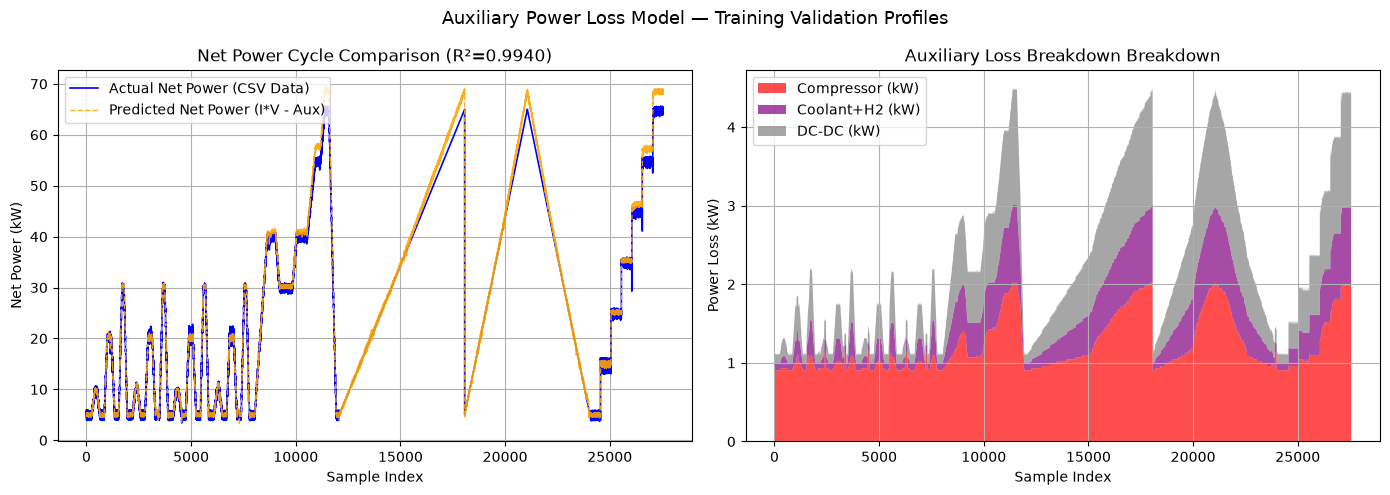


Saved: aux_model_params.pkl
  P_ref=897.5W | N_ref=5423.8RPM | small_fraction=1.36%

Cell 12 complete — compute_net_power() and aux_params in memory.
Run inference cell next.
df_id: gross_max=74.0kW | net_max=65.6kW | t_start=22.0°C | rows=12077
df_ramp: gross_max=73.5kW | net_max=65.0kW | t_start=22.0°C | rows=5991
df_noisy: gross_max=73.4kW | net_max=65.0kW | t_start=21.0°C | rows=5990
df_warm: gross_max=73.7kW | net_max=65.6kW | t_start=47.0°C | rows=3493
['Time', 'Power Request', 'Power Difference', 'Air Intake Pressure', 'H2 Intake Pressure', 'Main Coolant Flow Rate', 'Bypass Flow Rate', 'Coolant Inlet Temp', 'Coolant Outlet Temp', 'Output Voltage', 'Output Current', 'Net Power Output', 'Gross Power', 'Air Compressor RPM', 'H2 Consumption']
        Gross Power  Net Power Output
count  12077.000000      12077.000000
mean   22372.456678      19969.280450
std    17852.807059      16239.709007
min     4357.500000       3400.000000
25%     6735.400000       5700.000000
50%    16193.84

In [14]:
# ==============================================================================
# CELL 12: AUXILIARY POWER LOSS MODEL — Fully Self-Contained
# ==============================================================================
# Fits P_ref and N_ref from training data.
# Defines and saves compute_net_power() logic.
# Does NOT apply to new test data — that happens in inference cell.
#
# Requires: df_id, df_ramp, df_noisy (from Cell 2)
# Saves:    aux_model_params.pkl
# ==============================================================================

import numpy as np
import joblib
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

P_atm = 101325.0

# ── 1. FIT P_ref AND N_ref FROM TRAINING DATA ─────────────────────────────────
comp_rpm_all = np.concatenate([df_id['air_compressor'].values,
                                df_ramp['air_compressor'].values,
                                df_noisy['air_compressor'].values,
                                df_warm['air_compressor'].values])
p_gross_all  = np.concatenate([df_id['power_gross'].values,
                                df_ramp['power_gross'].values,
                                df_noisy['power_gross'].values,
                                df_warm['power_gross'].values])
p_net_all    = np.concatenate([df_id['power_net'].values,
                                df_ramp['power_net'].values,
                                df_noisy['power_net'].values,
                                df_warm['power_net'].values])

N_ref           = np.mean(comp_rpm_all)
affinity_basis  = (comp_rpm_all / N_ref) ** 3
p_converter_all = p_gross_all * 0.02
p_aux_total_all = p_gross_all - p_net_all

# Fit compressor P_ref in isolation
A_comp = affinity_basis.reshape(-1, 1)
P_ref  = np.linalg.lstsq(A_comp, p_aux_total_all - p_converter_all, rcond=None)[0][0]
P_ref  = np.clip(P_ref, 500, 15000)

# Small pumps — fixed from literature (Mirai II, ScienceDirect 2025)
# Coolant pump + H2 recirc = ~1.5kW at 110kW output = 1.36% of gross
AUX_SMALL_FRACTION = 0.0136

print(f"Compressor reference point:")
print(f"  N_ref               : {N_ref:.1f} RPM")
print(f"  P_ref               : {P_ref:.1f} W")
print(f"  Small pump fraction : {AUX_SMALL_FRACTION*100:.2f}% of gross (literature)")

# ── 2. DEFINE compute_net_power() ─────────────────────────────────────────────
def compute_net_power(p_gross, air_pressure_pa):
    """
    Computes net power and auxiliary loss breakdown.

    Inputs:
      p_gross          — gross power array (W), V_final * I_pred
      air_pressure_pa  — predicted air pressure array (Pa)

    Returns:
      p_net, p_comp, p_aux_small, p_converter  — all in W
    """
    # Derive compressor RPM from air pressure via affinity law
    # Validated: correlation with measured RPM on Baseline = 0.985
    comp_rpm    = N_ref * ((air_pressure_pa / P_atm) ** 0.5)

    p_comp      = P_ref * (comp_rpm / N_ref) ** 3
    p_aux_small = p_gross * AUX_SMALL_FRACTION
    p_converter = p_gross * 0.02
    p_net       = p_gross - p_comp - p_aux_small - p_converter

    return p_net, p_comp, p_aux_small, p_converter

# ── 3. VALIDATE ON TRAINING DATA ──────────────────────────────────────────────
# Use real measured air pressure to derive comp_rpm for validation
air_p_all = np.concatenate([df_id['air_p'].values,
                             df_ramp['air_p'].values,
                             df_noisy['air_p'].values,
                             df_warm['air_p'].values])

p_net_train_pred, p_comp_tr, p_small_tr, p_conv_tr = \
    compute_net_power(p_gross_all, air_p_all)

r2_train   = r2_score(p_net_all, p_net_train_pred)
rmse_train = np.sqrt(np.mean((p_net_train_pred - p_net_all)**2))

print(f"\nAuxiliary model — training validation:")
print(f"  R²   : {r2_train:.4f}")
print(f"  RMSE : {rmse_train:.1f} W  ({rmse_train/1000:.2f} kW)")

# Breakdown at mean operating point
p_gross_mean                                    = np.mean(p_gross_all)
air_p_mean                                      = np.mean(air_p_all)
_, p_comp_mean, p_small_mean, p_conv_mean       = compute_net_power(
    np.array([p_gross_mean]), np.array([air_p_mean])
)
print(f"\nAuxiliary breakdown at mean gross power ({p_gross_mean/1000:.1f} kW):")
print(f"  Compressor      : {p_comp_mean[0]/1000:.2f} kW")
print(f"  Coolant + H2    : {p_small_mean[0]/1000:.2f} kW")
print(f"  DC-DC converter : {p_conv_mean[0]/1000:.2f} kW")
print(f"  Total aux loss  : {(p_comp_mean[0]+p_small_mean[0]+p_conv_mean[0])/1000:.2f} kW")
print(f"\nNote: Radiator fans excluded (insufficient data).")

# ── 4. VALIDATION PLOTS ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Auxiliary Power Loss Model — Training Validation Profiles', fontsize=13)

# LEFT PLOT: Sequential Net Power Cycle Graph (Time/Sample Series)
sample_indices = range(len(p_net_all))
axes[0].plot(sample_indices, p_net_all / 1000, 
             color='blue', linewidth=1.2, label='Actual Net Power (CSV Data)')
axes[0].plot(sample_indices, p_net_train_pred / 1000, 
             color='orange', linewidth=1.0, linestyle='--', alpha=0.9, label='Predicted Net Power (I*V - Aux)')
axes[0].set_title(f'Net Power Cycle Comparison (R²={r2_train:.4f})')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Net Power (kW)')
axes[0].legend(loc='upper left')
axes[0].grid(True)

# RIGHT PLOT: Auxiliary breakdown stacked over training timeline
axes[1].stackplot(sample_indices,
    p_comp_tr  / 1000,
    p_small_tr / 1000,
    p_conv_tr  / 1000,
    labels=['Compressor (kW)', 'Coolant+H2 (kW)', 'DC-DC (kW)'],
    colors=['red', 'purple', 'gray'], alpha=0.7
)
axes[1].set_title('Auxiliary Loss Breakdown Breakdown')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Power Loss (kW)')
axes[1].legend(loc='upper left')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# ── 5. SAVE PARAMETERS ────────────────────────────────────────────────────────
aux_params = {
    'P_ref'             : P_ref,
    'N_ref'             : N_ref,
    'AUX_SMALL_FRACTION': AUX_SMALL_FRACTION,
    'P_atm'             : P_atm,
}
joblib.dump(aux_params, 'aux_model_params.pkl', compress = 3)
print(f"\nSaved: aux_model_params.pkl")
print(f"  P_ref={P_ref:.1f}W | N_ref={N_ref:.1f}RPM | "
      f"small_fraction={AUX_SMALL_FRACTION*100:.2f}%")
print(f"\nCell 12 complete — compute_net_power() and aux_params in memory.")
print(f"Run inference cell next.")

for name, df in [('df_id', df_id), ('df_ramp', df_ramp), ('df_noisy', df_noisy), ('df_warm', df_warm)]:
    print(f"{name}: gross_max={df['power_gross'].max()/1000:.1f}kW | "
          f"net_max={df['power_net'].max()/1000:.1f}kW | "
          f"t_start={df['T_in_K'].values[0]-273.15:.1f}°C | "
          f"rows={len(df)}")
    
import pandas as pd
raw_check = pd.read_csv('NEDC_ML_ECU_TRAINING.csv')
print(raw_check.columns.tolist())
print(raw_check[['Gross Power', 'Net Power Output']].describe())

Testing Against Baseline Test 15 June

# ============================================================
# INFERENCE CELL — Full Digital Twin Prediction
# ============================================================
# Inputs:
#   - CSV with Time + Power Request columns
#   - Starting coolant temperature (°C)
#   - Relative humidity (0-1)
#
# Requires in memory (Cells 1-12):
#   SOLVED_PARAMS, all ECU models, svr_model, scaler_svr,
#   compute_net_power(), P_atm, cp_coolant, Area
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── INITIAL CONDITIONS ────────────────────────────────────────
NEW_TEST_FILE   = input("Enter test CSV filename: ")
T_START_CELSIUS = float(input("Enter starting coolant temperature (°C): "))
RH_INITIAL      = float(input("Enter relative humidity (0 to 1, e.g. 0.48): "))

t_in_init  = T_START_CELSIUS + 273.15
lab_rh_new = RH_INITIAL

# ── 1. LOAD CSV ───────────────────────────────────────────────
raw_new = pd.read_csv(NEW_TEST_FILE)

def find_col(df, candidates):
    for c in candidates:
        matches = [col for col in df.columns if c.lower() in col.lower()]
        if matches:
            return matches[0]
    raise ValueError(f"Could not find column matching: {candidates}\n"
                     f"Available: {list(df.columns)}")

time_arr  = raw_new[find_col(raw_new, ['time'])].values
power_arr = raw_new[find_col(raw_new, ['power request', 'power_request'])].values
dt_new    = time_arr[1] - time_arr[0]
N         = len(time_arr)

print(f"\nLoaded : {N} timesteps | dt={dt_new:.2f}s | duration={time_arr[-1]:.1f}s")
print(f"Power  : {power_arr.min():.0f}W — {power_arr.max():.0f}W")
print(f"T_init : {T_START_CELSIUS:.1f}°C  |  RH: {RH_INITIAL*100:.0f}%")

# ── 2. BASE DataFrame ─────────────────────────────────────────
df_new = pd.DataFrame({
    'time'          : time_arr,
    'power_request' : power_arr,
    'T_in_K'        : np.full(N, t_in_init),
})

# ── 3. ECU SUB-MODELS ─────────────────────────────────────────
print("\nRunning ECU sub-models...")

current_density_new = ecu_current.predict(build_ecu_features(df_new))
current_pred_new    = current_density_new * Area
print(f"  Current      : {current_pred_new.min():.1f} — {current_pred_new.max():.1f} A")

h2_pred_new = h2_regressor.predict(power_arr.reshape(-1, 1))
# Note: H2 systematic offset ~200kPa — June 15 one-off (300 bar cylinder)
print(f"  H2 pressure  : {(h2_pred_new/1000).min():.1f} — {(h2_pred_new/1000).max():.1f} kPa")

air_pred_new = ecu_air.predict(build_ecu_features_air(df_new))
print(f"  Air pressure : {(air_pred_new/1000).min():.1f} — {(air_pred_new/1000).max():.1f} kPa")

bp_pred_new = ecu_bp.predict(build_ecu_features_bp(df_new))
bp_lmin_new = (bp_pred_new * 60) / 1.065
print(f"  Bypass flow  : {bp_lmin_new.min():.1f} — {bp_lmin_new.max():.1f} L/min")

wp_pred_new = ecu_wp.predict(build_ecu_features_wp(df_new))
wp_rpm_new  = wp_pred_new * 60
print(f"  Coolant pump : {wp_rpm_new.min():.1f} — {wp_rpm_new.max():.1f} RPM")

dt_new_thermal = time_arr[1] - time_arr[0]
cum_energy_new = np.cumsum(power_arr) * dt_new_thermal
cum_energy_id  = np.cumsum(df_id['power_request'].values) * dt_id

#####TESTING PLEASE BE AWARE OF THIS.
print(f"New test max cumulative energy : {cum_energy_new.max()/1e6:.2f} MJ")
print(f"NEDC max cumulative energy     : {cum_energy_id.max()/1e6:.2f} MJ")
print(f"Ramp max cumulative energy     : {(np.cumsum(df_ramp['power_request'].values)*dt_ramp).max()/1e6:.2f} MJ")
print(f"Hysteresis max cumulative energy: {(np.cumsum(df_noisy['power_request'].values)*dt_noisy).max()/1e6:.2f} MJ")



tin_pred_new  = ecu_tin.predict(build_thermal_features(df_new)) + t_in_init
m_dot_new     = bp_pred_new + (wp_pred_new * 1e-6)
tout_pred_new = tin_pred_new + (power_arr * 0.45) / (m_dot_new * cp_coolant)
print(f"  T_in         : {(tin_pred_new-273.15).min():.1f} — {(tin_pred_new-273.15).max():.1f} °C")
print(f"  T_out        : {(tout_pred_new-273.15).min():.1f} — {(tout_pred_new-273.15).max():.1f} °C")

# ── 4. AUTONOMOUS DataFrame (physics units) ───────────────────
df_new_auto = df_new.copy()
df_new_auto['current_density'] = current_density_new
df_new_auto['h2_p']            = h2_pred_new
df_new_auto['air_p']           = air_pred_new
df_new_auto['bypass_flow']     = bp_pred_new
df_new_auto['wp_rps']          = wp_pred_new
df_new_auto['T_in_K']          = tin_pred_new
df_new_auto['T_out_K']         = tout_pred_new

# ── 5. PHYSICS LOOP ───────────────────────────────────────────
# Adjust k_lambda if RH differs from training value
params_inference = SOLVED_PARAMS.copy()
lambda_base_train = calculate_lambda_base(LAB_RH)
lambda_base_new   = calculate_lambda_base(lab_rh_new)
if abs(lab_rh_new - LAB_RH) > 0.01:
    params_inference[3] = SOLVED_PARAMS[3] * (lambda_base_new / lambda_base_train)
    print(f"\nRH adjustment: k_lambda {SOLVED_PARAMS[3]:.4f} -> {params_inference[3]:.4f}")
else:
    print(f"\nRH close to training value — no adjustment needed")

print("Running physics loop...")
V_phys_new, T_stack_new = predict_voltage_loop(
    params_inference, df_new_auto, dt_new, t_in_init
)
print(f"  Voltage (physics): {V_phys_new.min():.1f} — {V_phys_new.max():.1f} V")

# ── 6. SVR CORRECTION ─────────────────────────────────────────
print("Applying SVR correction...")
X_new_svr        = build_svr_features(df_new_auto, V_phys_new)
X_new_svr_scaled = scaler_svr.transform(X_new_svr)
svr_corr_new     = np.clip(svr_model.predict(X_new_svr_scaled), -10, 10)
V_final_new      = V_phys_new + svr_corr_new
print(f"  SVR correction  : {svr_corr_new.min():.3f} — {svr_corr_new.max():.3f} V")
print(f"  Voltage (final) : {V_final_new.min():.1f} — {V_final_new.max():.1f} V")

# ── 7. AUXILIARY POWER LOSSES (from Cell 12) ──────────────────
print("Computing auxiliary power losses...")
p_gross_new     = V_final_new * current_pred_new
p_net_new, p_comp_loss_new, p_aux_small_new, p_converter_new = \
    compute_net_power(p_gross_new, air_pred_new)
p_aux_total_new = p_comp_loss_new + p_aux_small_new + p_converter_new

print(f"  Gross power     : {np.mean(p_gross_new)/1000:.2f} kW (mean)")
print(f"  Net power       : {np.mean(p_net_new)/1000:.2f} kW (mean)")
print(f"  Total aux loss  : {np.mean(p_aux_total_new)/1000:.2f} kW (mean)")

# ── 8. OUTPUT CSV ─────────────────────────────────────────────
df_out = pd.DataFrame({
    'time_s'                  : time_arr,
    'power_request_W'         : power_arr,
    'pred_current_A'          : current_pred_new,
    'pred_h2_pressure_kPa'    : h2_pred_new   / 1000,
    'pred_air_pressure_kPa'   : air_pred_new  / 1000,
    'pred_bypass_flow_Lmin'   : bp_lmin_new,
    'pred_coolant_pump_RPM'   : wp_rpm_new,
    'pred_T_in_C'             : tin_pred_new  - 273.15,
    'pred_T_out_C'            : tout_pred_new - 273.15,
    'pred_T_stack_C'          : T_stack_new   - 273.15,
    'pred_voltage_physics_V'  : V_phys_new,
    'svr_correction_V'        : svr_corr_new,
    'pred_voltage_final_V'    : V_final_new,
    'pred_gross_power_W'      : p_gross_new,
    'pred_aux_load_total_W'   : p_aux_total_new,
    'pred_net_power_W'        : p_net_new,
})

df_out.to_csv('digital_twin_predictions.csv', index=False)
print(f"\nSaved: digital_twin_predictions.csv "
      f"({len(df_out)} rows, {len(df_out.columns)} cols)")

# ── 9. PLOTS ──────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(21, 14))
fig.suptitle(f'Digital Twin  |  T={T_START_CELSIUS}°C  RH={RH_INITIAL*100:.0f}%',
             fontsize=15, fontweight='bold')

axes[0,0].plot(time_arr, V_final_new, color='orange', linewidth=0.9, label='Final')
axes[0,0].plot(time_arr, V_phys_new,  color='gray',   linewidth=0.8, alpha=0.5,
               label='Physics only')
axes[0,0].set_title('Stack Voltage'); axes[0,0].set_xlabel('Time (s)')
axes[0,0].set_ylabel('Voltage (V)'); axes[0,0].legend(); axes[0,0].grid(True)

axes[0,1].plot(time_arr, current_pred_new, color='orange', linewidth=0.8)
axes[0,1].set_title('Current Output'); axes[0,1].set_xlabel('Time (s)')
axes[0,1].set_ylabel('Current (A)'); axes[0,1].grid(True)

axes[0,2].plot(time_arr, svr_corr_new, color='purple', linewidth=0.8)
axes[0,2].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[0,2].set_title(f'SVR Correction (mean={np.mean(svr_corr_new):.3f}V)')
axes[0,2].set_xlabel('Time (s)'); axes[0,2].set_ylabel('Correction (V)')
axes[0,2].grid(True)

axes[1,0].plot(time_arr, h2_pred_new  / 1000, color='orange', linewidth=0.8, label='H2')
axes[1,0].plot(time_arr, air_pred_new / 1000, color='blue',   linewidth=0.8, label='Air')
axes[1,0].set_title('H2 & Air Pressure'); axes[1,0].set_xlabel('Time (s)')
axes[1,0].set_ylabel('Pressure (kPa)'); axes[1,0].legend(); axes[1,0].grid(True)

axes[1,1].plot(time_arr, tin_pred_new  - 273.15, color='blue',
               linewidth=0.8, label='T_in')
axes[1,1].plot(time_arr, tout_pred_new - 273.15, color='red',
               linewidth=0.8, label='T_out')
axes[1,1].plot(time_arr, T_stack_new   - 273.15, color='orange',
               linewidth=0.8, linestyle='--', label='T_stack')
axes[1,1].set_title('Temperatures'); axes[1,1].set_xlabel('Time (s)')
axes[1,1].set_ylabel('°C'); axes[1,1].legend(); axes[1,1].grid(True)

axes[1,2].plot(time_arr, bp_lmin_new, color='orange', linewidth=0.8,
               label='Bypass (L/min)')
ax_twin = axes[1,2].twinx()
ax_twin.plot(time_arr, wp_rpm_new, color='blue', linewidth=0.8, label='Pump (RPM)')
axes[1,2].set_title('Flow Rates'); axes[1,2].set_xlabel('Time (s)')
axes[1,2].set_ylabel('Bypass (L/min)', color='orange')
ax_twin.set_ylabel('Pump (RPM)', color='blue')
l1, lb1 = axes[1,2].get_legend_handles_labels()
l2, lb2 = ax_twin.get_legend_handles_labels()
axes[1,2].legend(l1+l2, lb1+lb2); axes[1,2].grid(True)

axes[2,0].plot(time_arr, p_gross_new / 1000, color='orange',
               linewidth=0.9, label='Gross (kW)')
axes[2,0].plot(time_arr, p_net_new   / 1000, color='green',
               linewidth=0.9, label='Net (kW)')
axes[2,0].plot(time_arr, power_arr   / 1000, color='blue',
               linewidth=0.8, linestyle='--', alpha=0.6, label='Request (kW)')
axes[2,0].set_title('Power'); axes[2,0].set_xlabel('Time (s)')
axes[2,0].set_ylabel('kW'); axes[2,0].legend(); axes[2,0].grid(True)

axes[2,1].plot(time_arr, p_aux_total_new / 1000, color='red', linewidth=0.8)
axes[2,1].set_title('Total Auxiliary Load')
axes[2,1].set_xlabel('Time (s)'); axes[2,1].set_ylabel('kW'); axes[2,1].grid(True)

axes[2,2].scatter(current_pred_new, V_final_new,
                  color='orange', s=2, alpha=0.4, label='Final')
axes[2,2].scatter(current_pred_new, V_phys_new,
                  color='gray',   s=2, alpha=0.3, label='Physics')
axes[2,2].set_title('Polarization Curve')
axes[2,2].set_xlabel('Current (A)'); axes[2,2].set_ylabel('Voltage (V)')
axes[2,2].legend(); axes[2,2].grid(True)

plt.tight_layout()
plt.savefig('digital_twin_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== DONE ===")
print(f"  CSV  : digital_twin_predictions.csv")
print(f"  Plot : digital_twin_predictions.png")
print(f"  T={T_START_CELSIUS}°C | RH={RH_INITIAL*100:.0f}%")